<a href="https://colab.research.google.com/github/JosePimienta/Colombia_Trafico_Portuario_Maritimo/blob/main/Colombia_Trafico_Portuario_Maritimo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
!pip install unidecode

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.colors as pc

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
df = pd.read_csv('/content/drive/MyDrive/BOOTCAMP UTB/Colombia_Trafico_Portuario_Maritimo.csv', encoding="utf-8")
df["SOCIEDAD PORTUARIA"] = df["SOCIEDAD PORTUARIA"].astype(str).str.encode("utf-8").str.decode("utf-8")


In [70]:
# Extraer valores únicos que contienen el carácter �
palabras_con_error = df['SOCIEDAD PORTUARIA'].dropna().unique()
palabras_con_error = [palabra for palabra in palabras_con_error if '�' in palabra]

# Mostrar el resultado
print(palabras_con_error)


['COMPA�IA DE PUERTOS ASOCIADOS S.A.', 'CENIT TRANSPORTE Y LOG�STICA DE HIDROCARBUROS SAS', 'C.I. UNI�N DE BANANEROS DE URABA - UNIBAN']


In [71]:
df['SOCIEDAD PORTUARIA'] = df['SOCIEDAD PORTUARIA'].str.replace('COMPA�IA', 'COMPAÑIA', regex=False)
df['SOCIEDAD PORTUARIA'] = df['SOCIEDAD PORTUARIA'].str.replace('LOG�STICA', 'LOGÍSTICA', regex=False)
df['SOCIEDAD PORTUARIA'] = df['SOCIEDAD PORTUARIA'].str.replace('UNI�N', 'UNIÓN', regex=False)

In [72]:
df['SOCIEDAD PORTUARIA'].unique()

array(['SOCIEDAD PORTUARIA MICHELLMAR S.A.',
       'SOCIEDAD PORTUARIA IMPALA TERMINALS BARRANCABERMEJA S.A.',
       'COMPAÑIA DE PUERTOS ASOCIADOS S.A.', 'VOPAK COLOMBIA S.A.',
       'ROMERO Y BURGOS & CIA S.EN C.',
       'SOCIEDAD PORTUARIA TRANSMARSYP S.A.', 'PUERTO BUENAVISTA S.A',
       'SOCIEDAD PORTUARIA TERMINAL DE CONTENEDORES DE BUENAVENTURA S.A.',
       'NUEVA SOCIEDAD PORTUARIA ZONA ATLANTICA S A',
       'SOCIEDAD PORTUARIA PUERTO BAHIA',
       'SOCIEDAD PUERTO INDUSTRIAL AGUADULCE S.A.',
       'PUERTO DE MAMONAL S.A.  EN REORGANIZACION EMPRESARIAL',
       'SAN ANDRES PORT SOCIETY SA', 'PORTUARIA PUNTA DE VACA S.A.',
       'SOCIEDAD PORTUARIA REGIONAL DE BARRANQUILLA S.A.',
       'PALERMO SOCIEDAD PORTUARIA S.A',
       'SOCIEDAD PORTUARIA RIVERPORT S.A.',
       'SOCIEDAD PORTUARIA DEXTON S.A.',
       'TERMINAL DE CONTENEDORES DE CARTAGENA S. A.',
       'SOCIEDAD PORTUARIA BAVARIA S.A', 'PUERTO BRISA S.A.',
       'COREMAR SHOREBASE SA', 'GRUPO PORTUARIO S.A'

In [73]:
# Limpiar los nombres de las columnas para evitar errores por espacios
df.columns = df.columns.str.strip()

In [74]:
print('Información del dataset\n')
print(df.info())

Información del dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8006 entries, 0 to 8005
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ZONA PORTUARIA          8006 non-null   object
 1   SOCIEDAD PORTUARIA      8006 non-null   object
 2   TIPO DE SERVICIO        8006 non-null   object
 3   TIPO DE CARGA           8006 non-null   object
 4   EXPORTACION             8006 non-null   int64 
 5   IMPORTACIÓN             8006 non-null   int64 
 6   TRANSBORDO              8006 non-null   int64 
 7   TRANSITO INTERNACIONAL  8006 non-null   int64 
 8   FLUVIAL                 8006 non-null   int64 
 9   CABOTAJE                8006 non-null   int64 
 10  MOVILIZACIONES A BORDO  8006 non-null   int64 
 11  TRANSITORIA             8006 non-null   int64 
 12  AÑO VIGENCIA            8006 non-null   int64 
 13  MES VIGENCIA            8006 non-null   int64 
dtypes: int64(10), object(4)
memory 

In [75]:
# Zonas únicas
zonas_unicas = df['ZONA PORTUARIA'].drop_duplicates().tolist()

# Crear datos como lista de listas
data = [[i, zona] for i, zona in enumerate(zonas_unicas)]

# Mostrar como tabla
print(tabulate(data, headers=["Índice", "zona"], tablefmt="grid"))

+----------+--------------------+
|   Índice | zona               |
+==========+====================+
|        0 | BARRANQUILLA       |
+----------+--------------------+
|        1 | BARRANCABERMEJA    |
+----------+--------------------+
|        2 | CARTAGENA          |
+----------+--------------------+
|        3 | TUMACO             |
+----------+--------------------+
|        4 | BUENAVENTURA       |
+----------+--------------------+
|        5 | SAN ANDRES         |
+----------+--------------------+
|        6 | G. MORROSQUILLO    |
+----------+--------------------+
|        7 | TURBO              |
+----------+--------------------+
|        8 | GUAJIRA            |
+----------+--------------------+
|        9 | CIENAGA            |
+----------+--------------------+
|       10 | SANTA MARTA        |
+----------+--------------------+
|       11 | Z.P. RIO MAGDALENA |
+----------+--------------------+


Puertos de Región 5 (Bolívar, Cordoba, Sucre, San andres) <br>
CARTAGENA<br>
SAN ANDRES<br>
G. MORROSQUILLO

Crear dataframe con puertos de la Región 5

In [76]:
# Puertos de región 5
region5 = ['CARTAGENA', 'SAN ANDRES', 'G. MORROSQUILLO']
df_region5 = df[df['ZONA PORTUARIA'].isin(region5)]
df_region5

,ZONA PORTUARIA,SOCIEDAD PORTUARIA,TIPO DE SERVICIO,TIPO DE CARGA,EXPORTACION,IMPORTACIÓN,TRANSBORDO,TRANSITO INTERNACIONAL,FLUVIAL,CABOTAJE,MOVILIZACIONES A BORDO,TRANSITORIA,AÑO VIGENCIA,MES VIGENCIA
4,CARTAGENA,VOPAK COLOMBIA S.A.,PUBLICO,GRANEL LIQUIDO,0,1096,0,0,0,0,0,0,2022,4
6,CARTAGENA,SOCIEDAD PORTUARIA TRANSMARSYP S.A.,PUBLICO,CONTENEDORES,0,0,0,0,0,4856,0,0,2023,12
7,CARTAGENA,SOCIEDAD PORTUARIA TRANSMARSYP S.A.,PUBLICO,CONTENEDORES,0,0,0,0,0,5081,0,0,2018,6
8,CARTAGENA,PUERTO BUENAVISTA S.A,PUBLICO,GENERAL,10481,0,0,0,0,340,0,0,2024,3
10,CARTAGENA,PUERTO BUENAVISTA S.A,PUBLICO,GENERAL,4498,0,0,0,0,768,0,0,2023,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8001,CARTAGENA,PUERTO DE MAMONAL S.A. EN REORGANIZACION EMPR...,PUBLICO,GRANEL LIQUIDO,2644,0,0,0,0,0,0,0,2024,12
8002,CARTAGENA,PUERTO DE MAMONAL S.A. EN REORGANIZACION EMPR...,PUBLICO,CONTENEDORES,0,74,0,0,0,0,0,0,2019,5
8003,CARTAGENA,PUERTO DE MAMONAL S.A. EN REORGANIZACION EMPR...,PUBLICO,GENERAL,8741,538,0,0,0,0,0,0,2022,5
8004,CARTAGENA,PUERTO DE MAMONAL S.A. EN REORGANIZACION EMPR...,PUBLICO,GENERAL,305,1216,0,0,0,0,0,0,2023,12


In [77]:
# Zonas únicas
zonas_unicas = df_region5['ZONA PORTUARIA'].drop_duplicates().tolist()

# Crear datos como lista de listas
data = [[i, zona] for i, zona in enumerate(zonas_unicas)]

# Mostrar como tabla
print(tabulate(data, headers=["Índice", "zona"], tablefmt="grid"))

+----------+-----------------+
|   Índice | zona            |
+==========+=================+
|        0 | CARTAGENA       |
+----------+-----------------+
|        1 | SAN ANDRES      |
+----------+-----------------+
|        2 | G. MORROSQUILLO |
+----------+-----------------+


In [78]:
print('Información del dataset\n')
df_region5.info()

Información del dataset

<class 'pandas.core.frame.DataFrame'>
Index: 3369 entries, 4 to 8005
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ZONA PORTUARIA          3369 non-null   object
 1   SOCIEDAD PORTUARIA      3369 non-null   object
 2   TIPO DE SERVICIO        3369 non-null   object
 3   TIPO DE CARGA           3369 non-null   object
 4   EXPORTACION             3369 non-null   int64 
 5   IMPORTACIÓN             3369 non-null   int64 
 6   TRANSBORDO              3369 non-null   int64 
 7   TRANSITO INTERNACIONAL  3369 non-null   int64 
 8   FLUVIAL                 3369 non-null   int64 
 9   CABOTAJE                3369 non-null   int64 
 10  MOVILIZACIONES A BORDO  3369 non-null   int64 
 11  TRANSITORIA             3369 non-null   int64 
 12  AÑO VIGENCIA            3369 non-null   int64 
 13  MES VIGENCIA            3369 non-null   int64 
dtypes: int64(10), object(4)
memory usage

In [79]:
#Revisar estadisticas descriptivas
print('\nEstadistica datos numéricos')
print(df_region5.describe())


Estadistica datos numéricos
        EXPORTACION   IMPORTACIÓN    TRANSBORDO  TRANSITO INTERNACIONAL  \
count  3.369000e+03  3.369000e+03  3.369000e+03             3369.000000   
mean   7.803993e+04  2.434335e+04  3.965084e+04              384.730781   
std    2.586870e+05  6.159647e+04  2.013331e+05             2976.535701   
min    0.000000e+00  0.000000e+00  0.000000e+00                0.000000   
25%    0.000000e+00  0.000000e+00  0.000000e+00                0.000000   
50%    0.000000e+00  2.173000e+03  0.000000e+00                0.000000   
75%    1.460000e+04  2.245500e+04  0.000000e+00                0.000000   
max    2.042645e+06  1.600188e+06  1.470313e+06            41477.000000   

           FLUVIAL      CABOTAJE  MOVILIZACIONES A BORDO  TRANSITORIA  \
count  3369.000000  3.369000e+03             3369.000000  3369.000000   
mean      7.126150  8.627042e+03                1.555061    11.282873   
std      87.280181  4.797926e+04               74.293246   165.653858   
min

In [80]:
print('\nEstadistica datos categóricos')
print(df_region5.describe(include='object'))


Estadistica datos categóricos
       ZONA PORTUARIA                  SOCIEDAD PORTUARIA TIPO DE SERVICIO  \
count            3369                                3369             3369   
unique              3                                  29                2   
top         CARTAGENA  COMPAÑIA DE PUERTOS ASOCIADOS S.A.          PUBLICO   
freq             2704                                 415             2758   

         TIPO DE CARGA  
count             3369  
unique               5  
top     GRANEL LIQUIDO  
freq              1269  


In [81]:
df_region5 = df_region5.copy()
# df_region5['AÑO VIGENCIA'] = pd.to_datetime(df_region5['AÑO VIGENCIA'], format='%Y')
# df_region5['MES VIGENCIA'] = pd.to_datetime(df_region5['MES VIGENCIA'], format='%m')
# df_region5
df_region5['Fecha'] = pd.to_datetime(
    df_region5['AÑO VIGENCIA'].astype(str) + "-" + df_region5['MES VIGENCIA'].astype(str) + "-01",
    format='%Y-%m-%d'
)
df_region5

,ZONA PORTUARIA,SOCIEDAD PORTUARIA,TIPO DE SERVICIO,TIPO DE CARGA,EXPORTACION,IMPORTACIÓN,TRANSBORDO,TRANSITO INTERNACIONAL,FLUVIAL,CABOTAJE,MOVILIZACIONES A BORDO,TRANSITORIA,AÑO VIGENCIA,MES VIGENCIA,Fecha
4,CARTAGENA,VOPAK COLOMBIA S.A.,PUBLICO,GRANEL LIQUIDO,0,1096,0,0,0,0,0,0,2022,4,2022-04-01
6,CARTAGENA,SOCIEDAD PORTUARIA TRANSMARSYP S.A.,PUBLICO,CONTENEDORES,0,0,0,0,0,4856,0,0,2023,12,2023-12-01
7,CARTAGENA,SOCIEDAD PORTUARIA TRANSMARSYP S.A.,PUBLICO,CONTENEDORES,0,0,0,0,0,5081,0,0,2018,6,2018-06-01
8,CARTAGENA,PUERTO BUENAVISTA S.A,PUBLICO,GENERAL,10481,0,0,0,0,340,0,0,2024,3,2024-03-01
10,CARTAGENA,PUERTO BUENAVISTA S.A,PUBLICO,GENERAL,4498,0,0,0,0,768,0,0,2023,12,2023-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8001,CARTAGENA,PUERTO DE MAMONAL S.A. EN REORGANIZACION EMPR...,PUBLICO,GRANEL LIQUIDO,2644,0,0,0,0,0,0,0,2024,12,2024-12-01
8002,CARTAGENA,PUERTO DE MAMONAL S.A. EN REORGANIZACION EMPR...,PUBLICO,CONTENEDORES,0,74,0,0,0,0,0,0,2019,5,2019-05-01
8003,CARTAGENA,PUERTO DE MAMONAL S.A. EN REORGANIZACION EMPR...,PUBLICO,GENERAL,8741,538,0,0,0,0,0,0,2022,5,2022-05-01
8004,CARTAGENA,PUERTO DE MAMONAL S.A. EN REORGANIZACION EMPR...,PUBLICO,GENERAL,305,1216,0,0,0,0,0,0,2023,12,2023-12-01


In [82]:
df_region5['MES VIGENCIA']

,MES VIGENCIA
4,4
6,12
7,6
8,3
10,12
...,...
8001,12
8002,5
8003,5
8004,12


In [83]:
# Mes a estudiar
mes = 6

In [84]:
# Filtrar solo los datos del mes seleccionado
df_mes = df_region5[df_region5["Fecha"].dt.month == mes]


Gráfico para CARTAGENA:


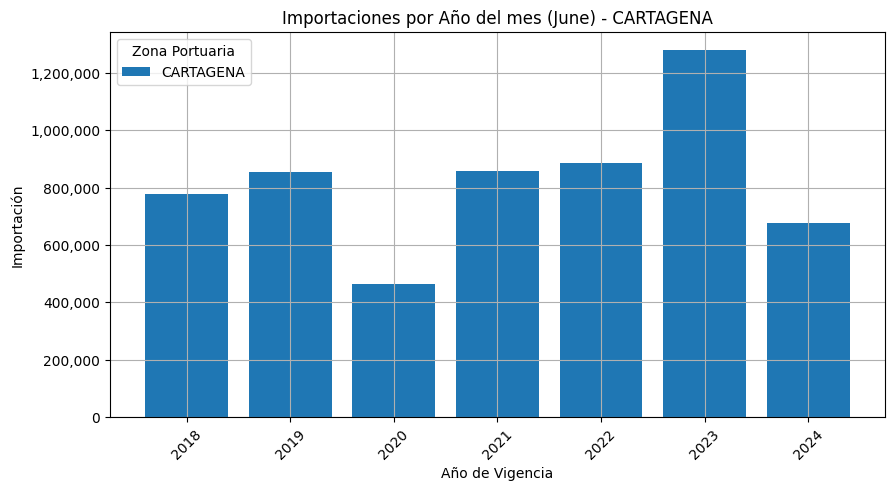


Gráfico para SAN ANDRES:


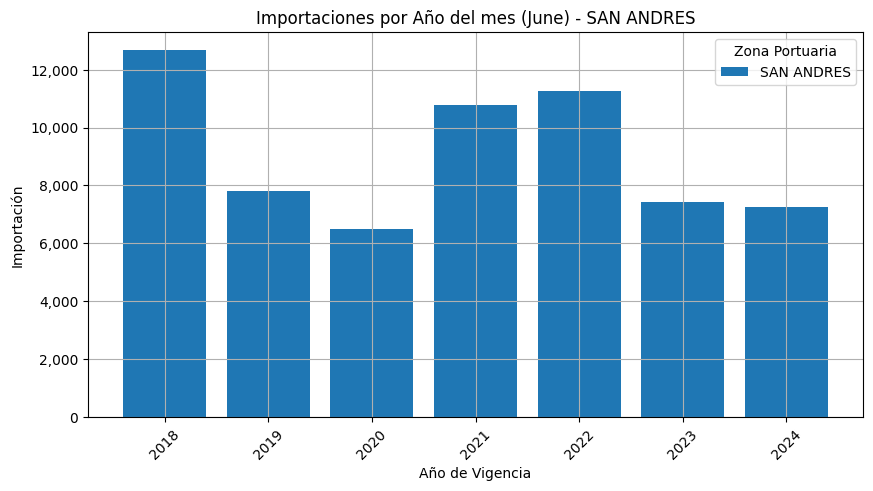


Gráfico para G. MORROSQUILLO:


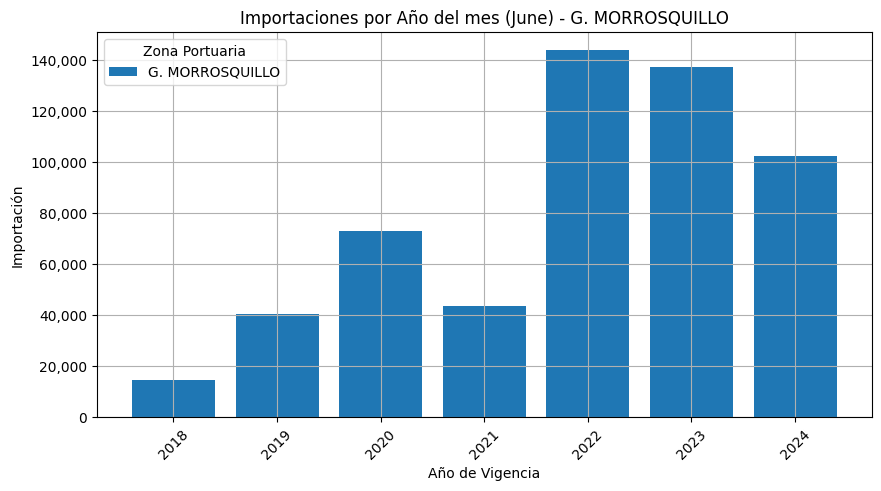

In [85]:
# Obtener el nombre del mes
nombre_mes = pd.to_datetime(str(mes), format='%m').strftime('%B')

# Iterar sobre cada zona y generar gráficos separados
for zona in zonas_unicas:
    print(f"\nGráfico para {zona}:")

    # Crear la figura
    plt.figure(figsize=(10, 5))

    # Filtrar los datos de la zona
    #df_zona = df_mes[df_mes['ZONA PORTUARIA'] == zona]
    df_zona = df_mes[df_mes['ZONA PORTUARIA'] == zona]

    # **Agrupar por "AÑO VIGENCIA" y sumar las importaciones**
    df_zona_agg = df_zona.groupby("AÑO VIGENCIA")["IMPORTACIÓN"].sum()

    # Graficar
    plt.bar(df_zona_agg.index, df_zona_agg.values, label=zona)

    # Configuración del gráfico
    plt.xticks(rotation=45)
    plt.title(f"Importaciones por Año del mes ({nombre_mes}) - {zona}")
    plt.xlabel("Año de Vigencia")
    plt.ylabel("Importación")

    # **Evitar notación científica**
    plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

    plt.legend(title="Zona Portuaria")
    plt.grid()
    plt.show()


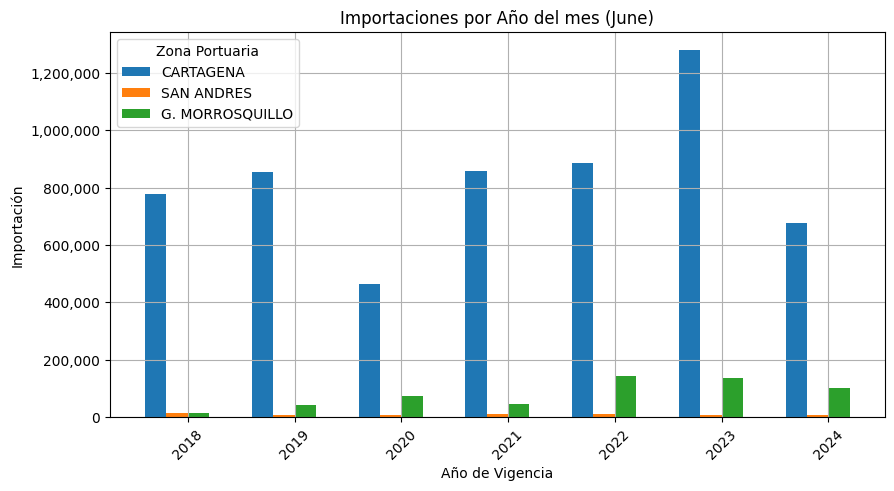

In [86]:
plt.figure(figsize=(10, 5))

# Obtener años únicos y definir posiciones en X
años_unicos = sorted(df_mes['AÑO VIGENCIA'].unique())
x = np.arange(len(años_unicos))
width = 0.2  # Ancho de las barras

# Graficar cada zona con desplazamiento en X
for i, zona in enumerate(zonas_unicas):
    #df_zona = df_mes[df_mes["ZONA PORTUARIA"] == zona]
    df_zona = df_mes[df_mes['ZONA PORTUARIA'] == zona]
    importaciones = [df_zona[df_zona["AÑO VIGENCIA"] == año]["IMPORTACIÓN"].sum() for año in años_unicos]
    plt.bar(x + i * width, importaciones, width=width, label=zona)

# Configurar eje X con los años
plt.xticks(x + (width * (len(zonas_unicas) / 2)), años_unicos, rotation=45)

plt.title(f"Importaciones por Año del mes ({nombre_mes})")
plt.xlabel("Año de Vigencia")
plt.ylabel("Importación")

# Evitar notación científica en eje Y
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

plt.legend(title="Zona Portuaria")
plt.grid()
plt.show()


In [87]:
# Tabla Cruzada (NO UTILIZADO)
tabla_cruzada = pd.crosstab(df_zona['IMPORTACIÓN'], df_zona['SOCIEDAD PORTUARIA'])
tabla_cruzada

SOCIEDAD PORTUARIA,CENIT TRANSPORTE Y LOGÍSTICA DE HIDROCARBUROS SAS,COMPAÑIA DE PUERTOS ASOCIADOS S.A.,OLEODUCTO CENTRAL S.A.
IMPORTACIÓN,,,
0,5,7,7
14353,0,1,0
40373,0,1,0
43309,0,1,0
59043,1,0,0
66801,0,1,0
72777,0,1,0
76863,1,0,0
77905,0,1,0



Gráfico para CARTAGENA:


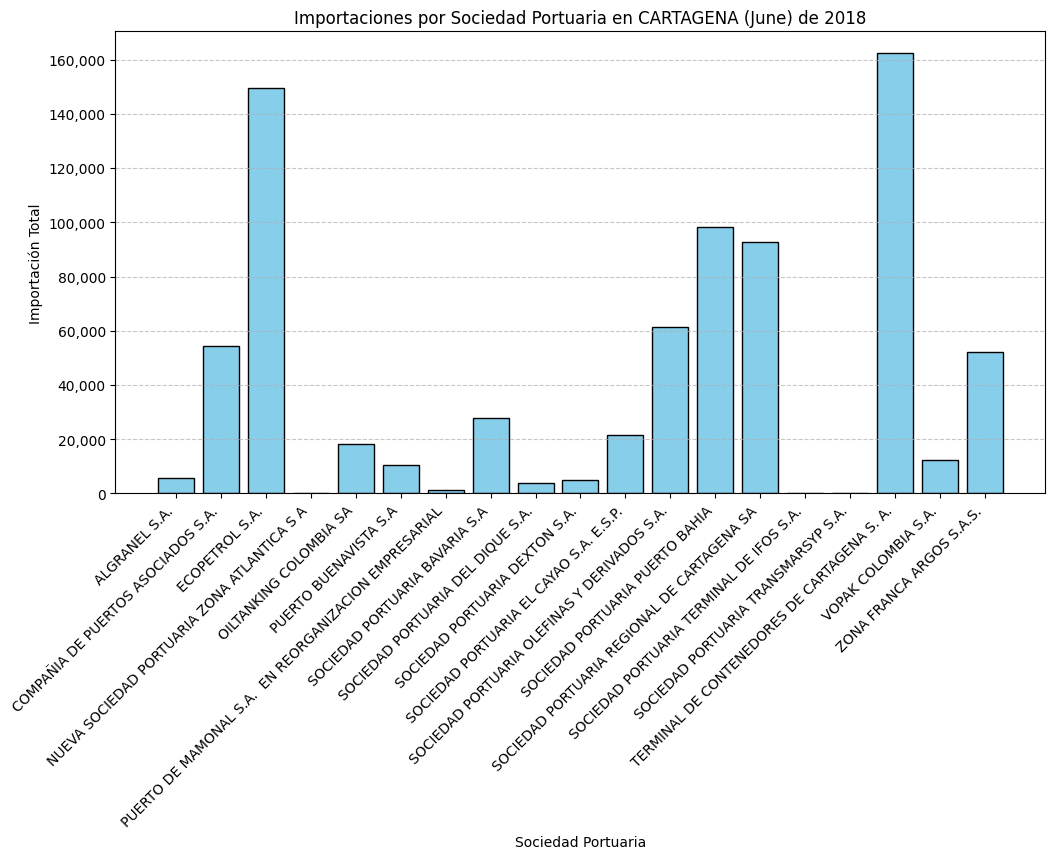


Gráfico para SAN ANDRES:


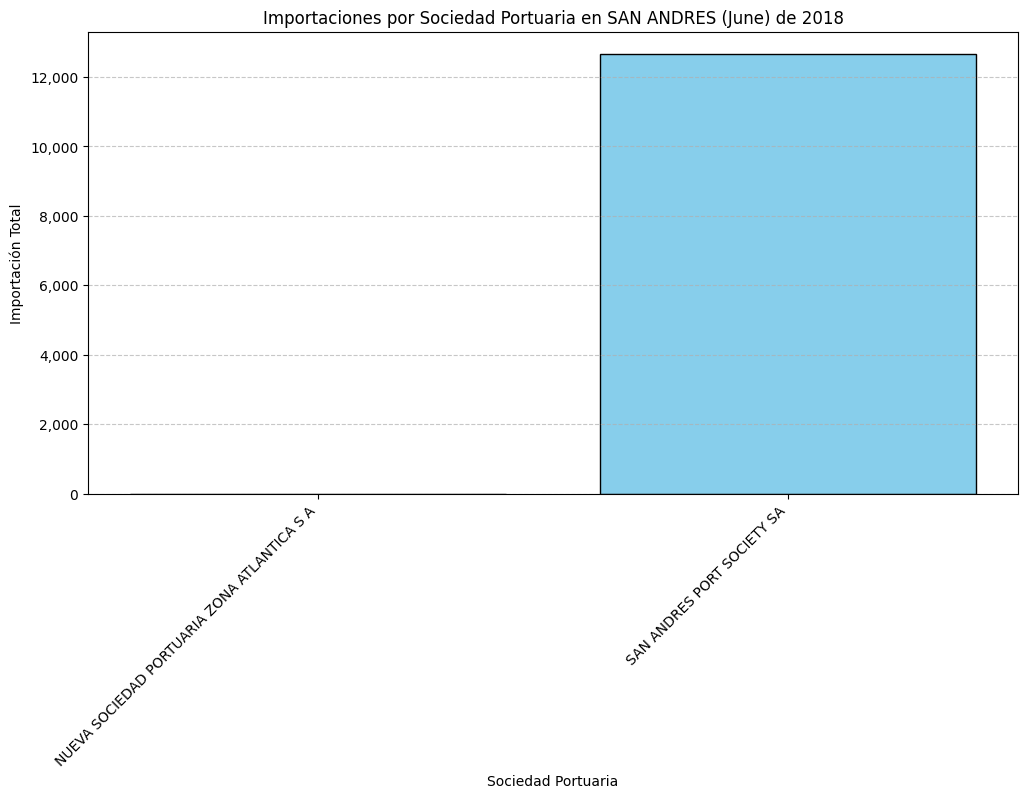


Gráfico para G. MORROSQUILLO:


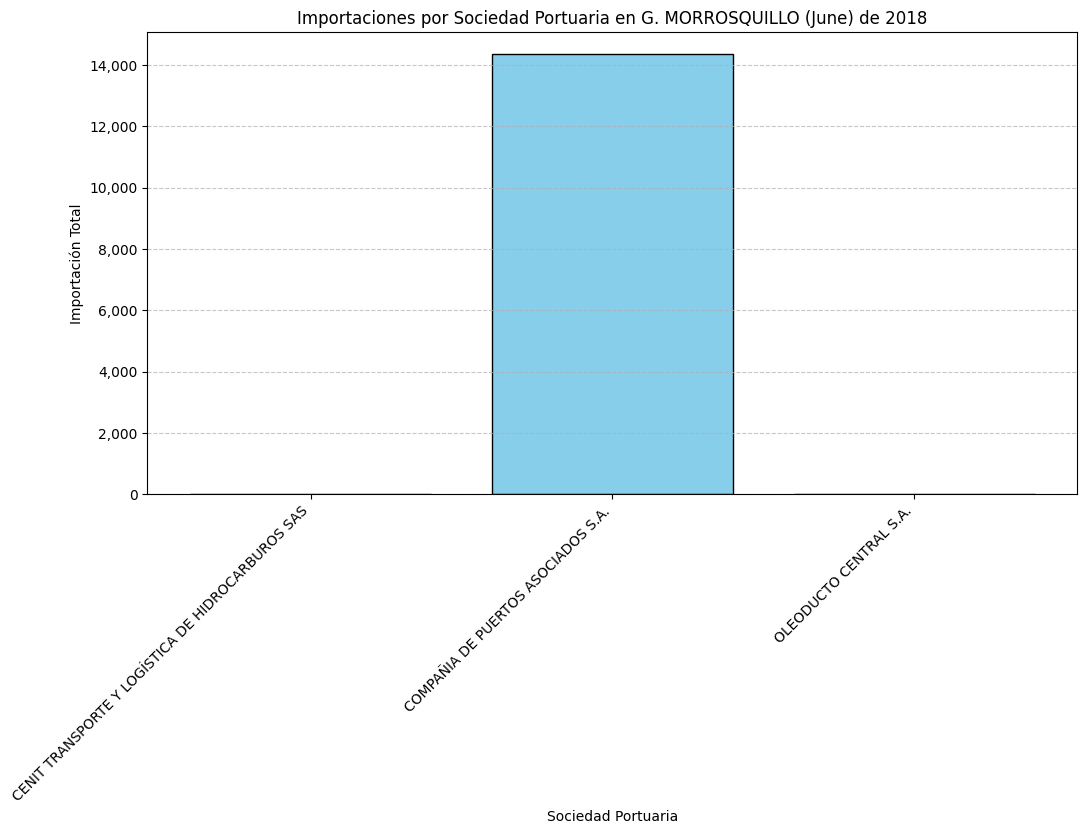

In [88]:
# Obtener el nombre del mes
nombre_mes = pd.to_datetime(str(mes), format='%m').strftime('%B')

# Iterar sobre cada zona portuaria para generar gráficos separados
for zona in zonas_unicas:
    print(f"\nGráfico para {zona}:")

    # Filtrar los datos de la zona actual
    df_zona = df_mes[df_mes["ZONA PORTUARIA"] == zona]
    df_zona = df_zona[df_zona['AÑO VIGENCIA'] == 2018]


    # **Agrupar por "SOCIEDAD PORTUARIA" y sumar importaciones**
    df_sociedad_agg = df_zona.groupby("SOCIEDAD PORTUARIA")["IMPORTACIÓN"].sum()

    # Crear la figura
    plt.figure(figsize=(12, 6))

    # Graficar las barras
    plt.bar(df_sociedad_agg.index, df_sociedad_agg.values, color='skyblue', edgecolor='black')

    # Configuración del gráfico
    plt.xticks(rotation=45, ha="right")  # Rotar etiquetas del eje X para mejor visibilidad
    plt.title(f"Importaciones por Sociedad Portuaria en {zona} ({nombre_mes}) de 2018")
    plt.xlabel("Sociedad Portuaria")
    plt.ylabel("Importación Total")

    # **Evitar notación científica en el eje Y**
    plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Agregar líneas de guía

    plt.show()



Gráficos para CARTAGENA en June:




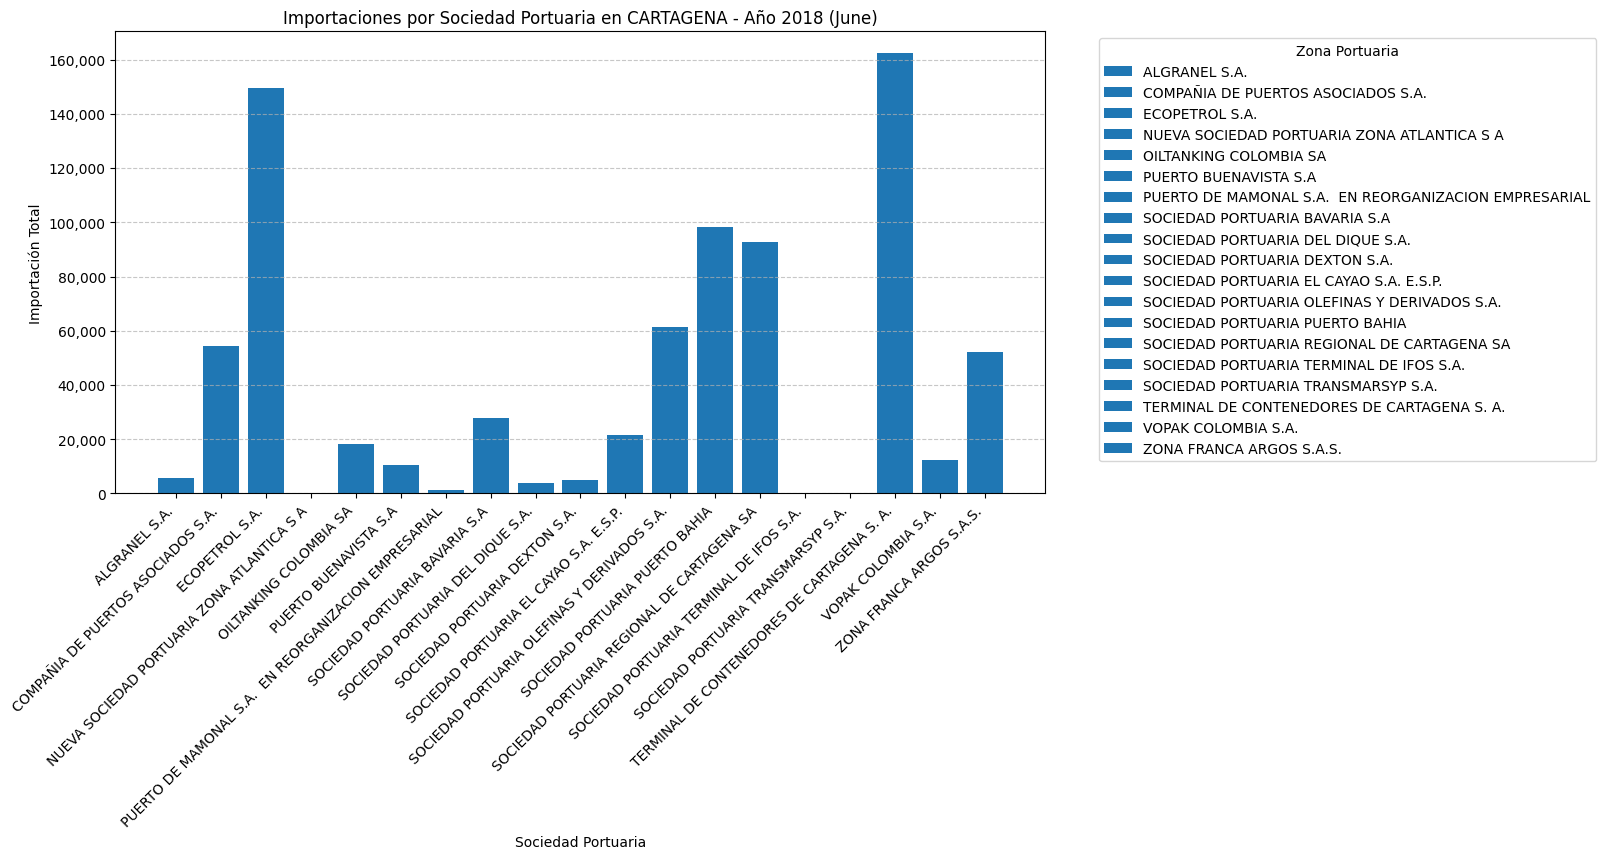

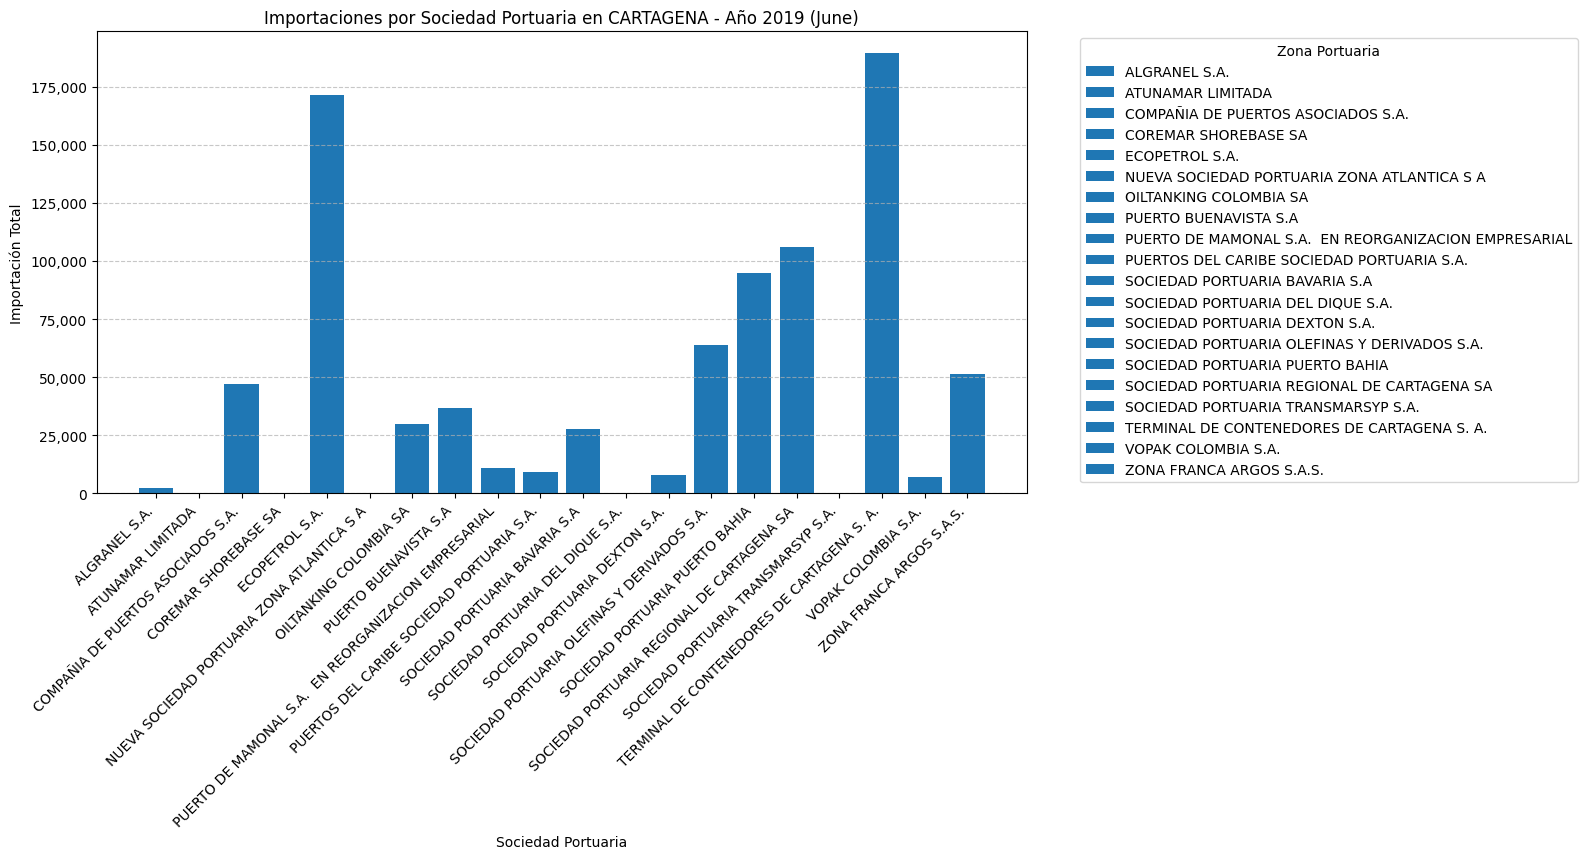

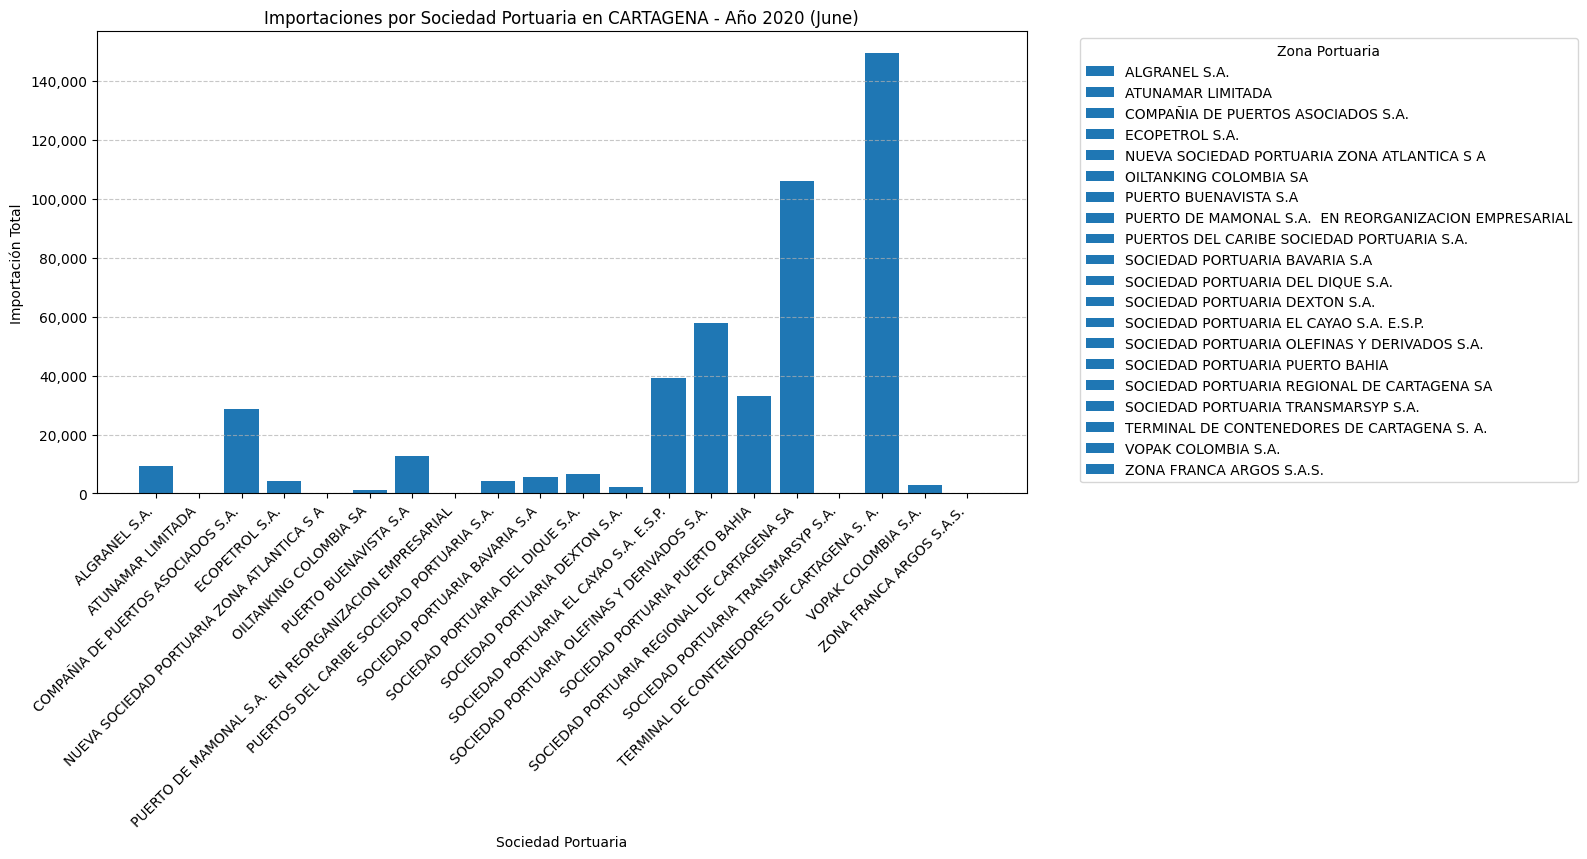

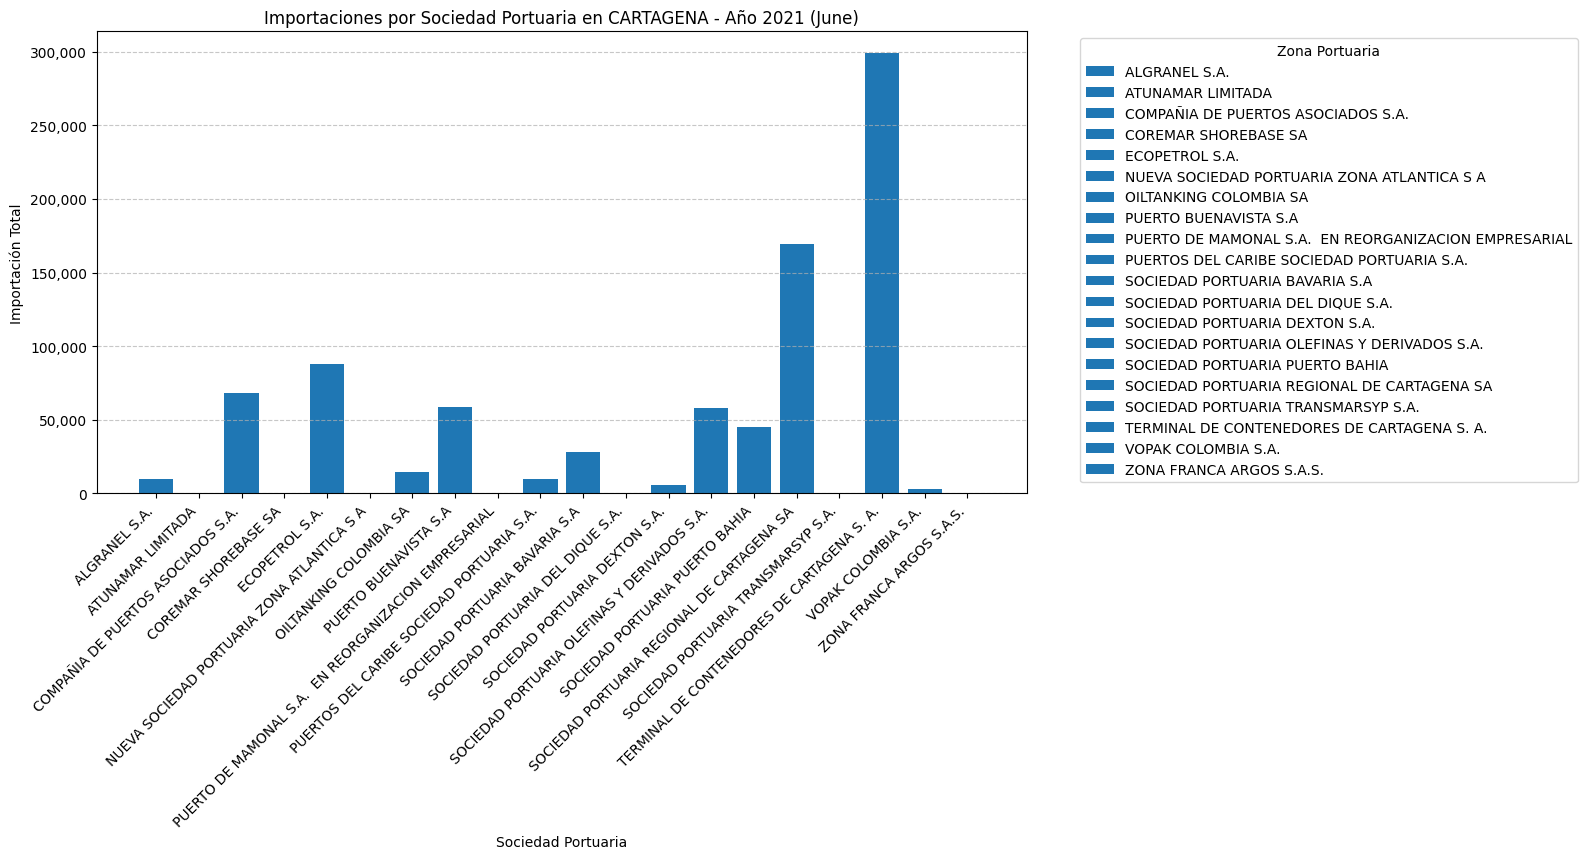

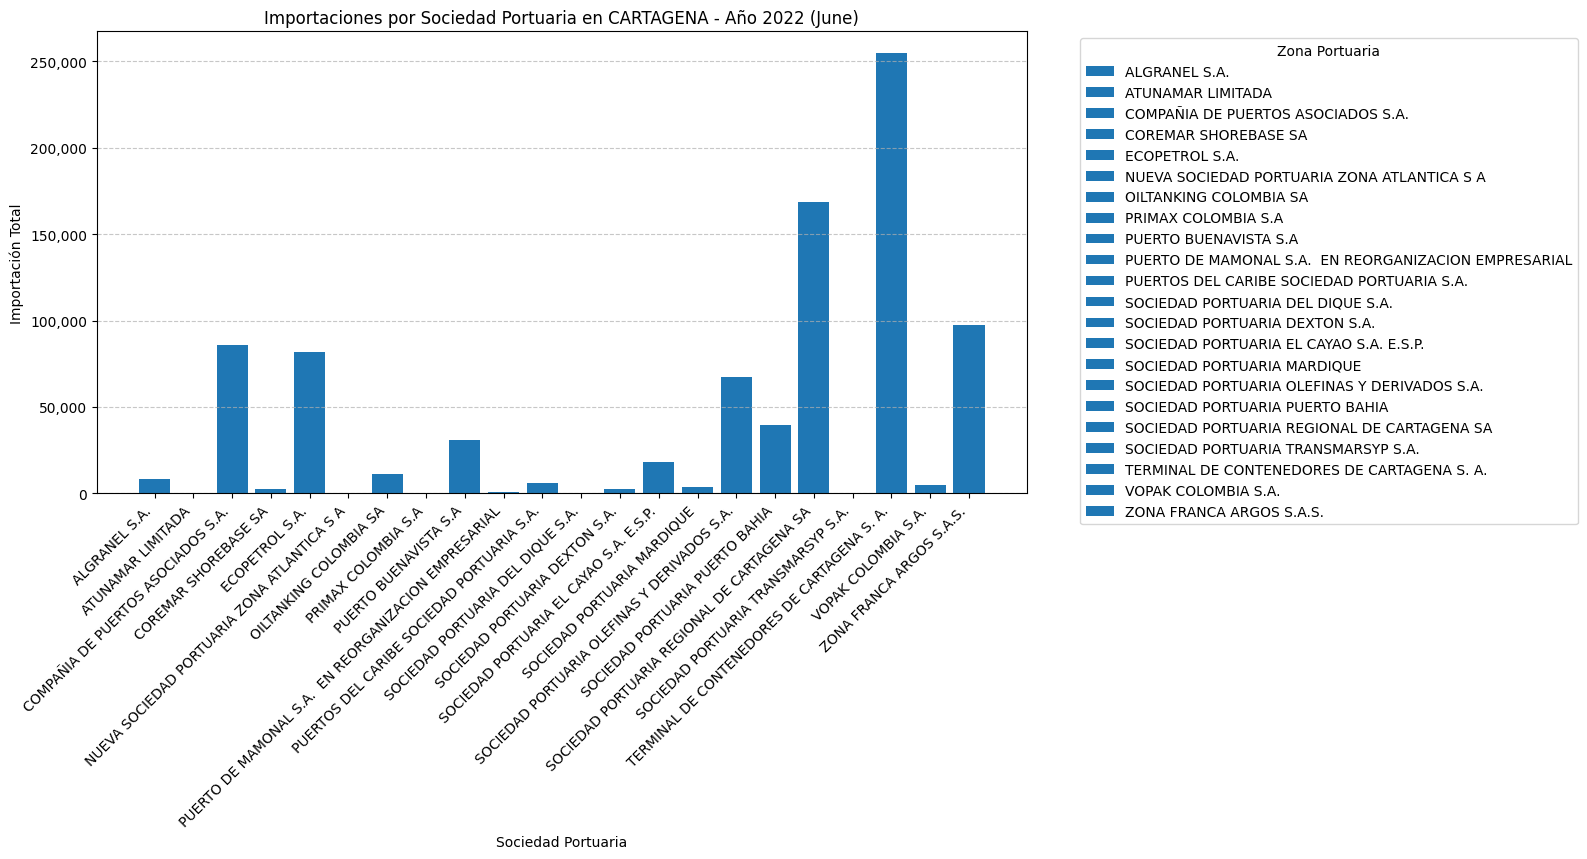

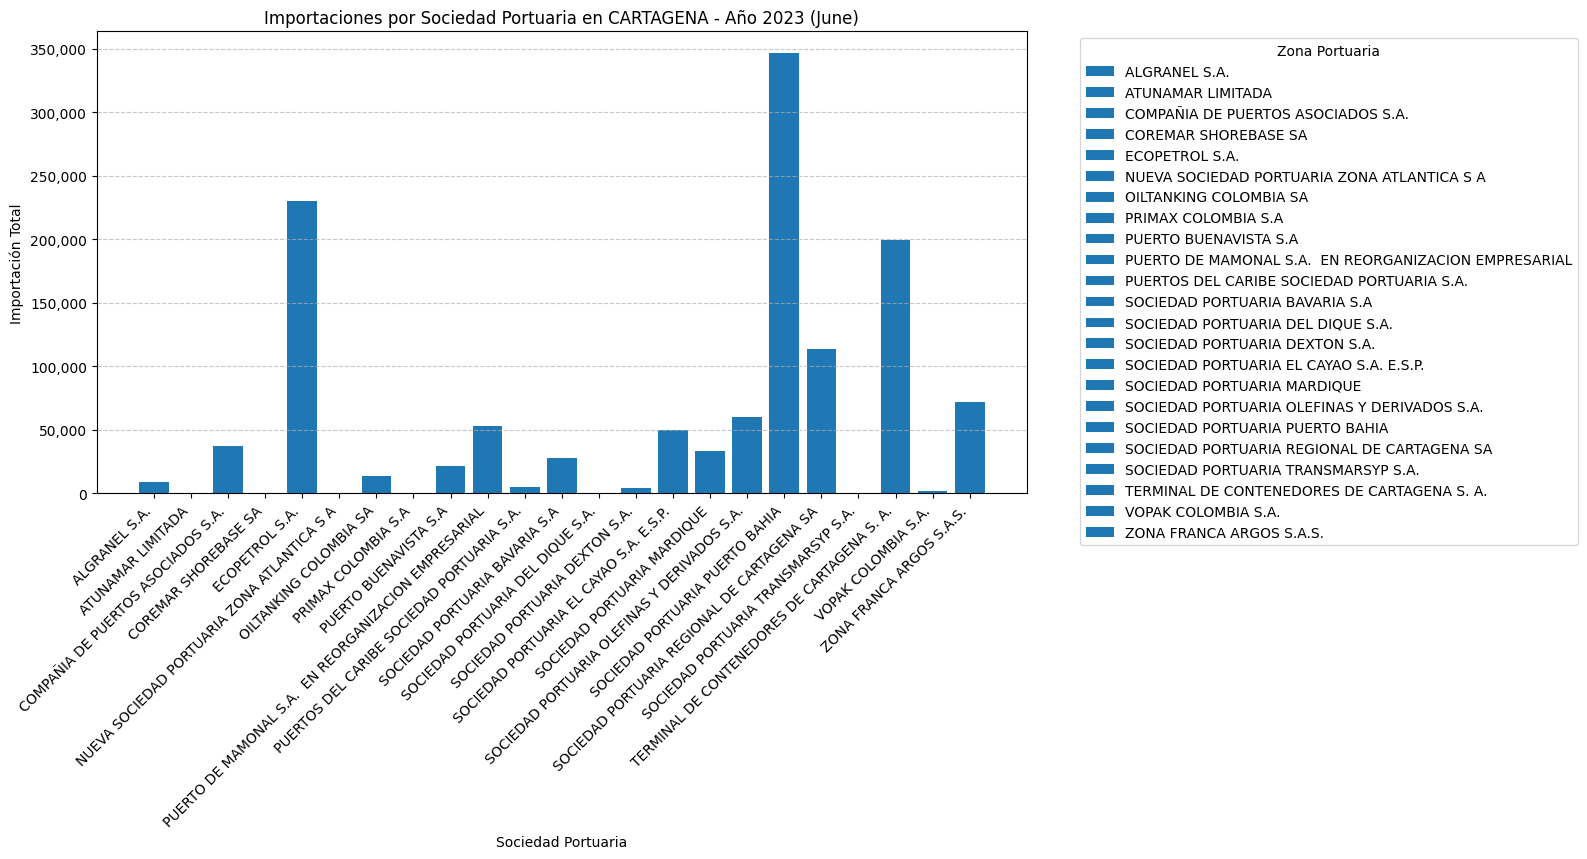

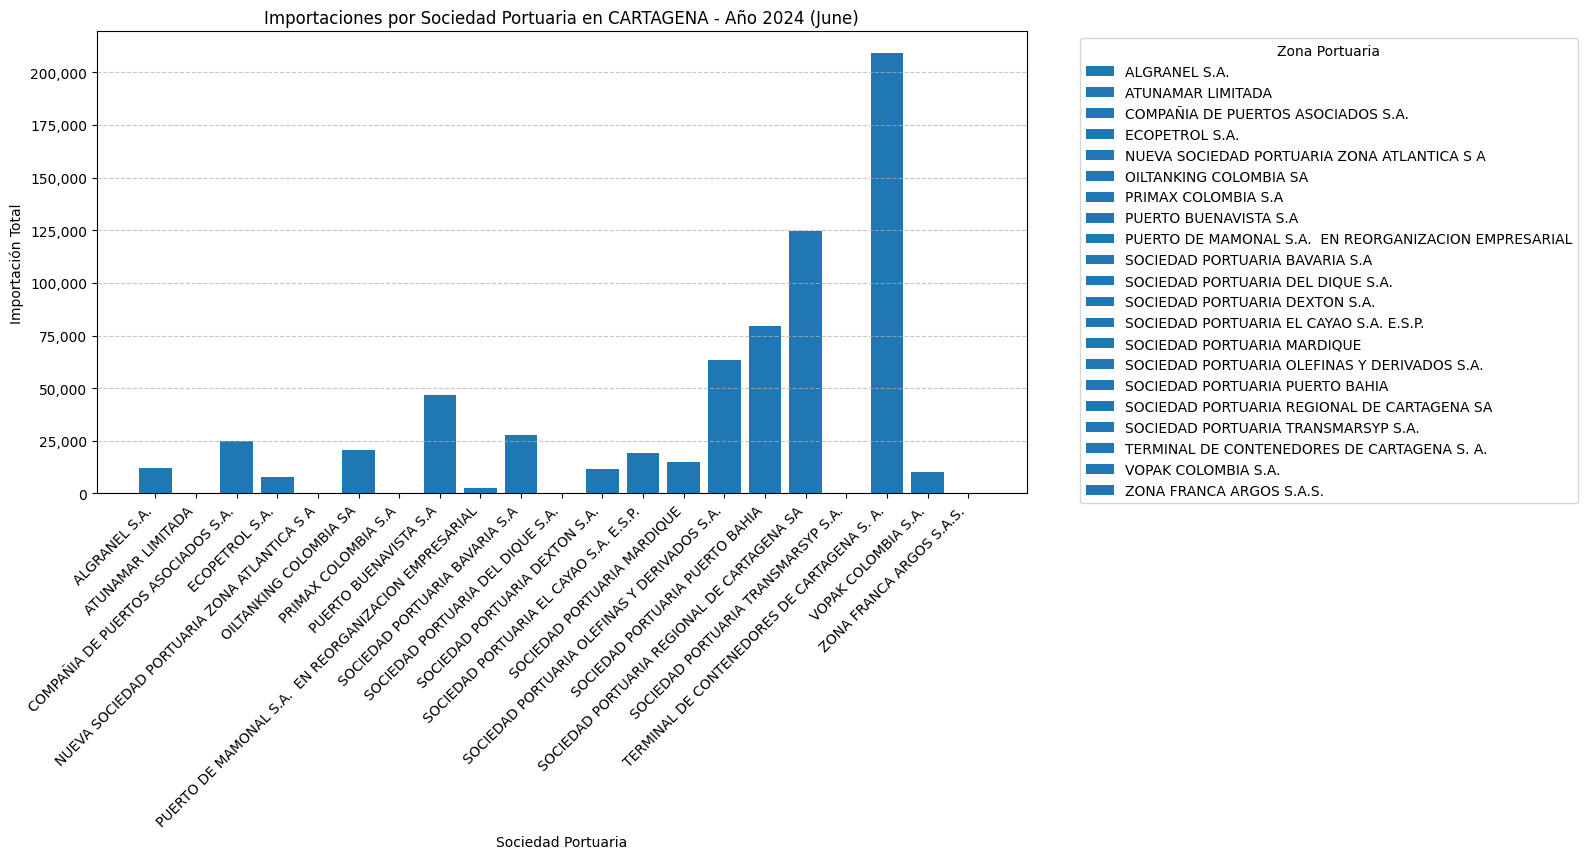


Gráficos para SAN ANDRES en June:




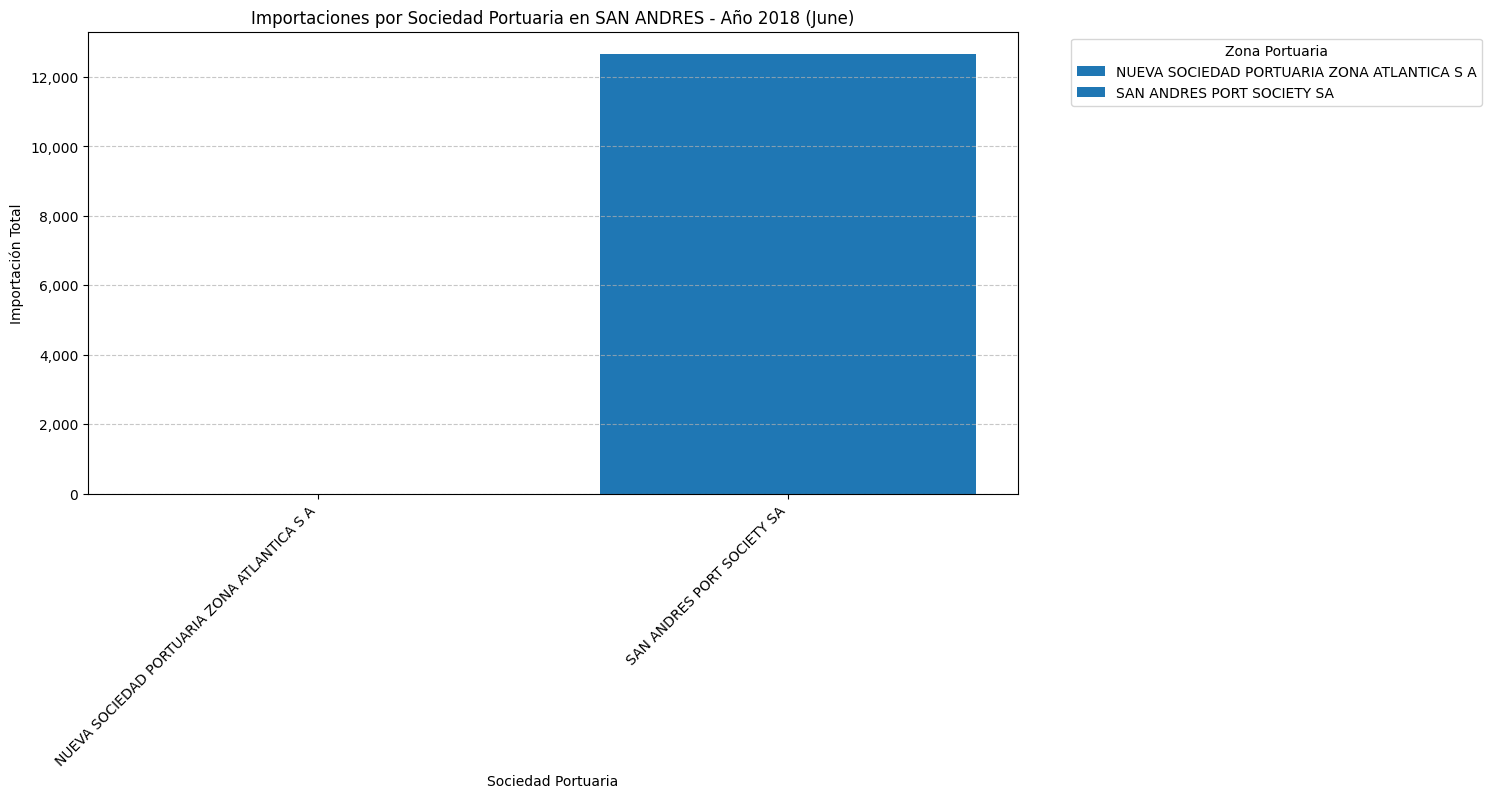

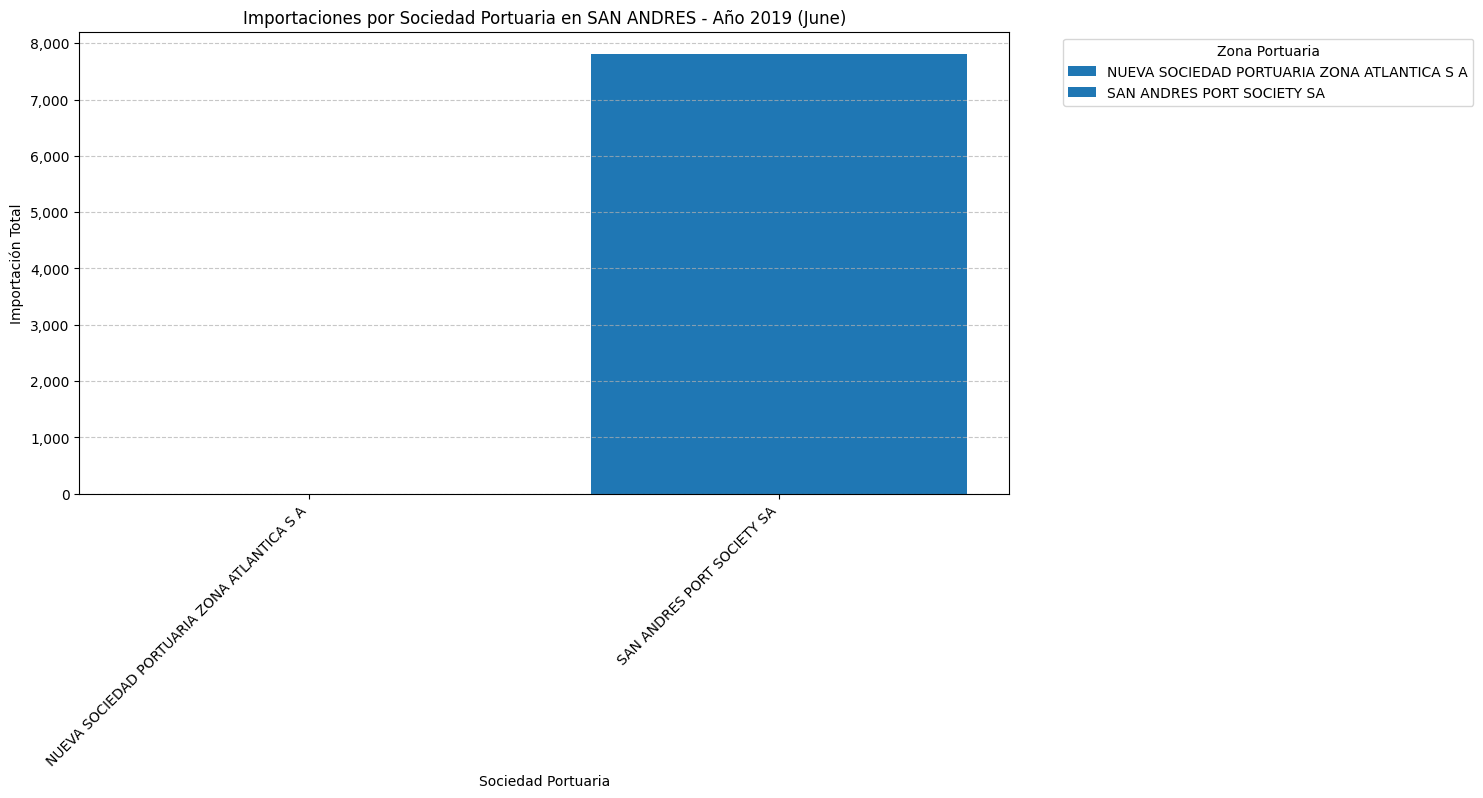

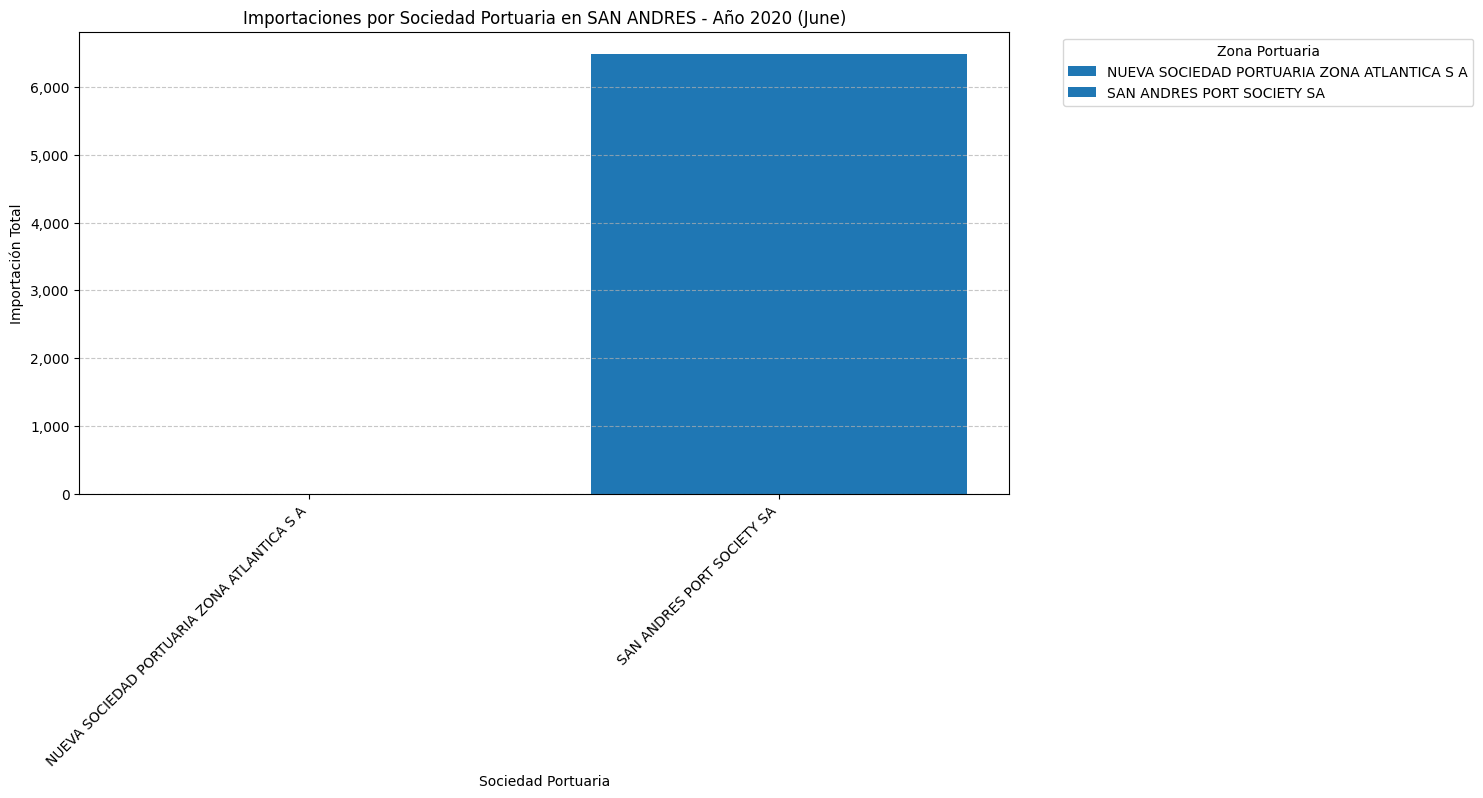

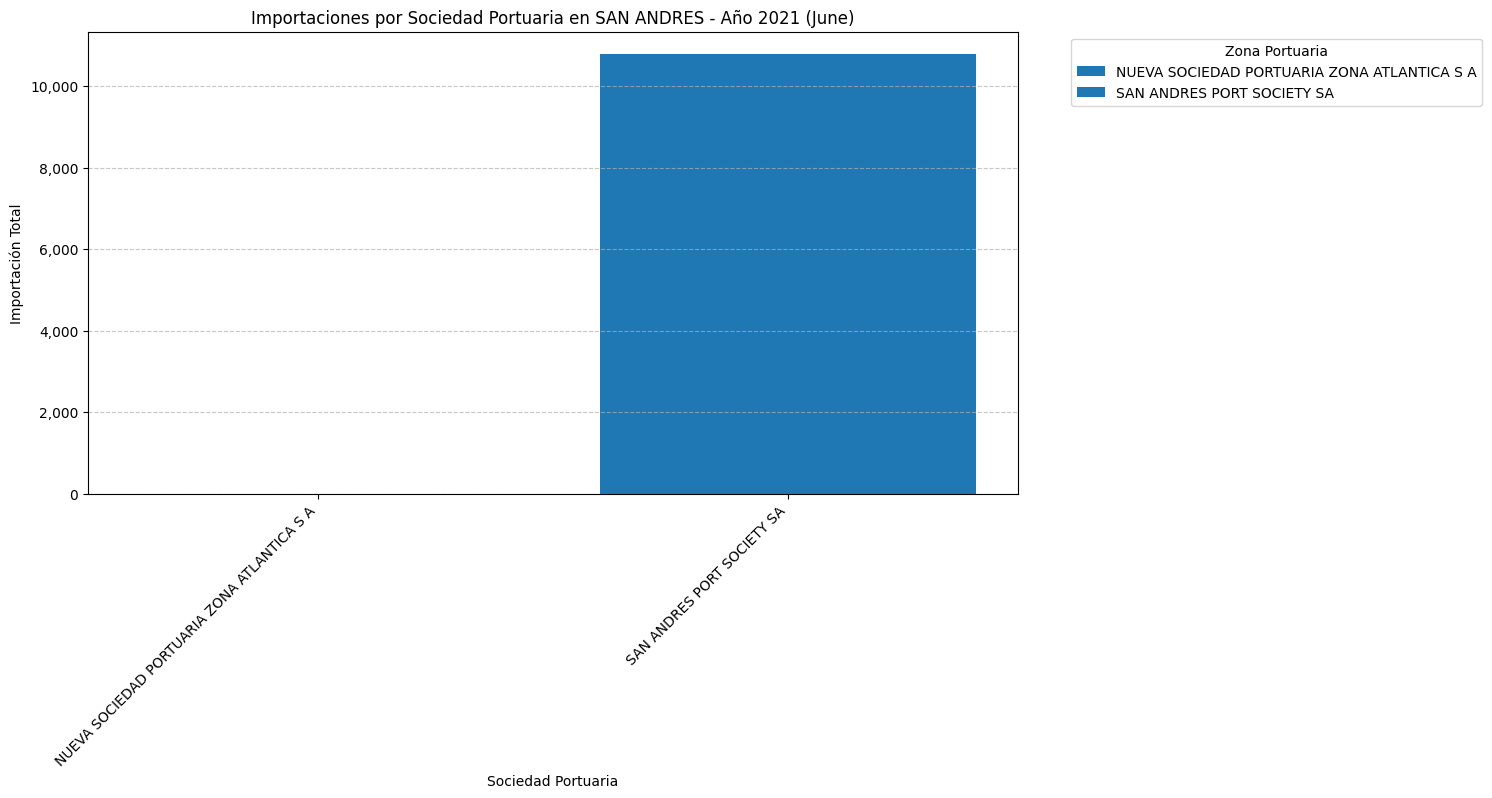

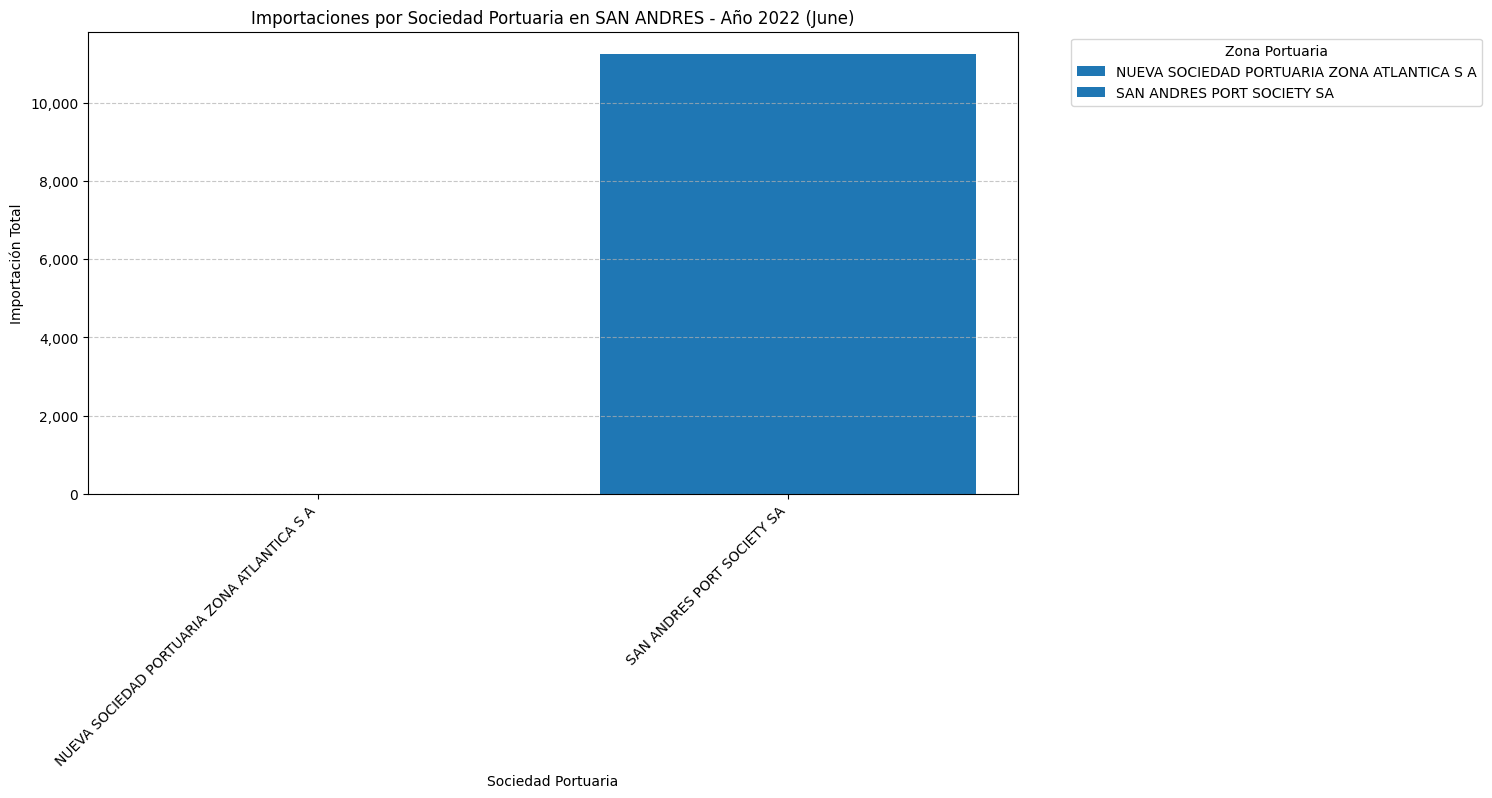

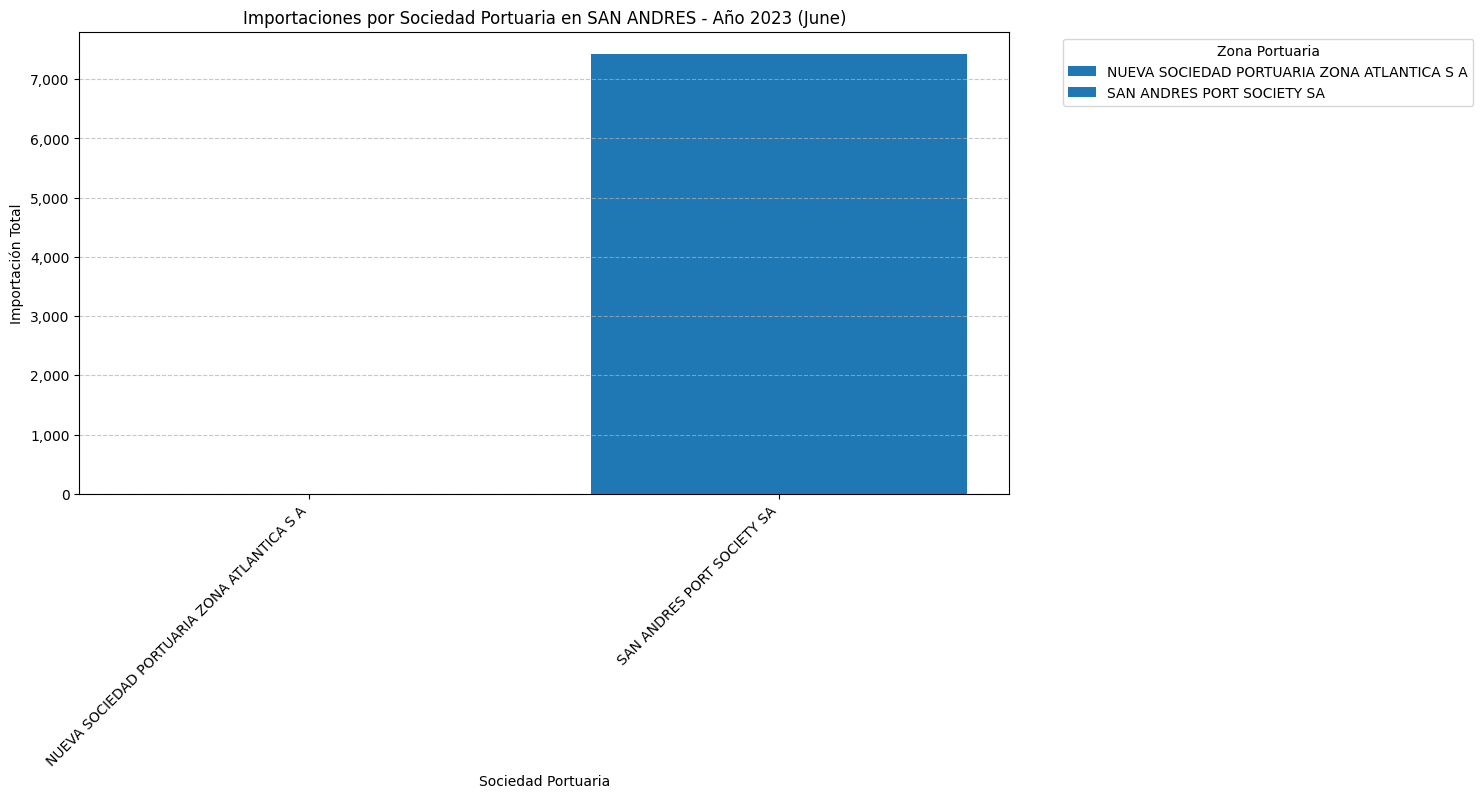

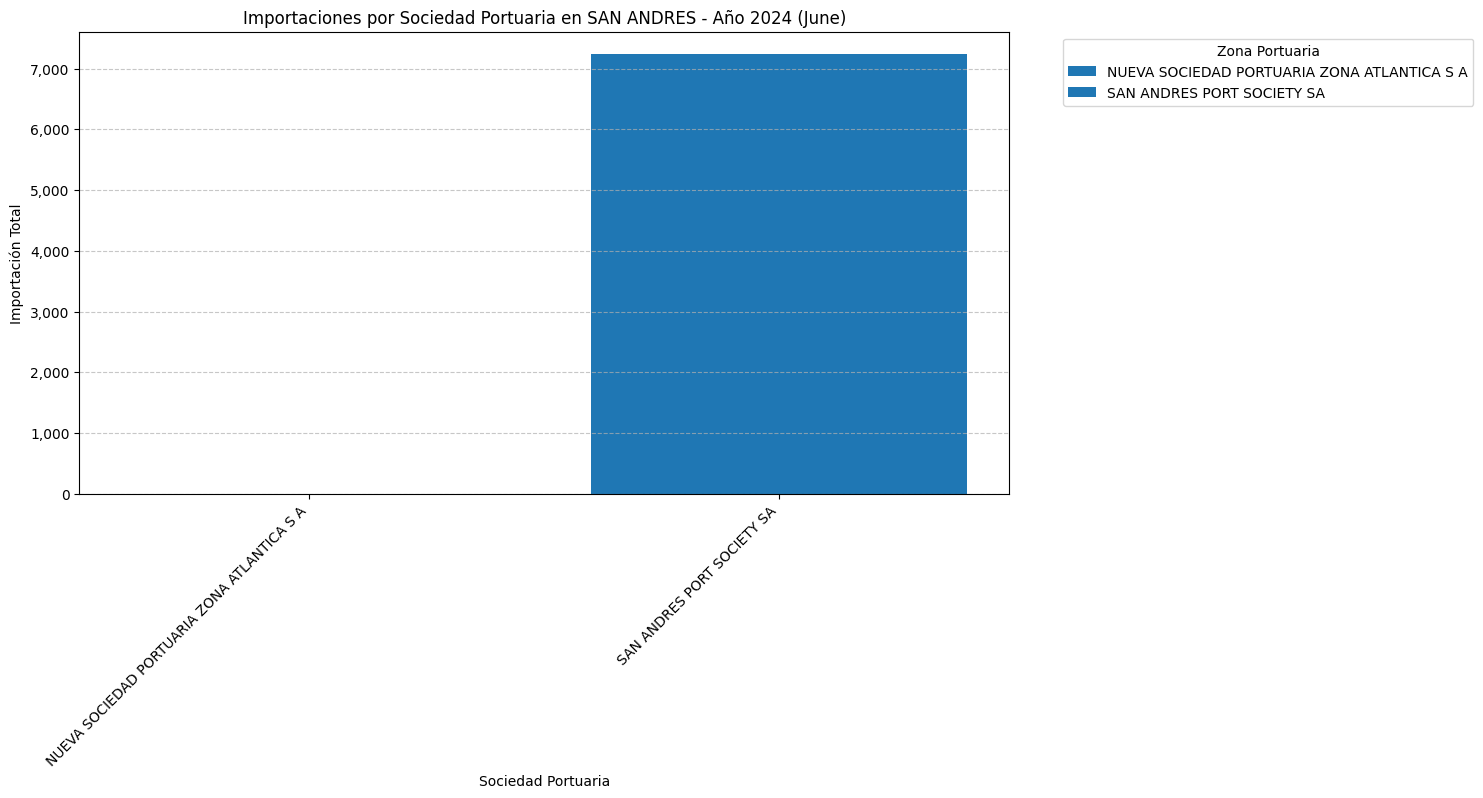


Gráficos para G. MORROSQUILLO en June:




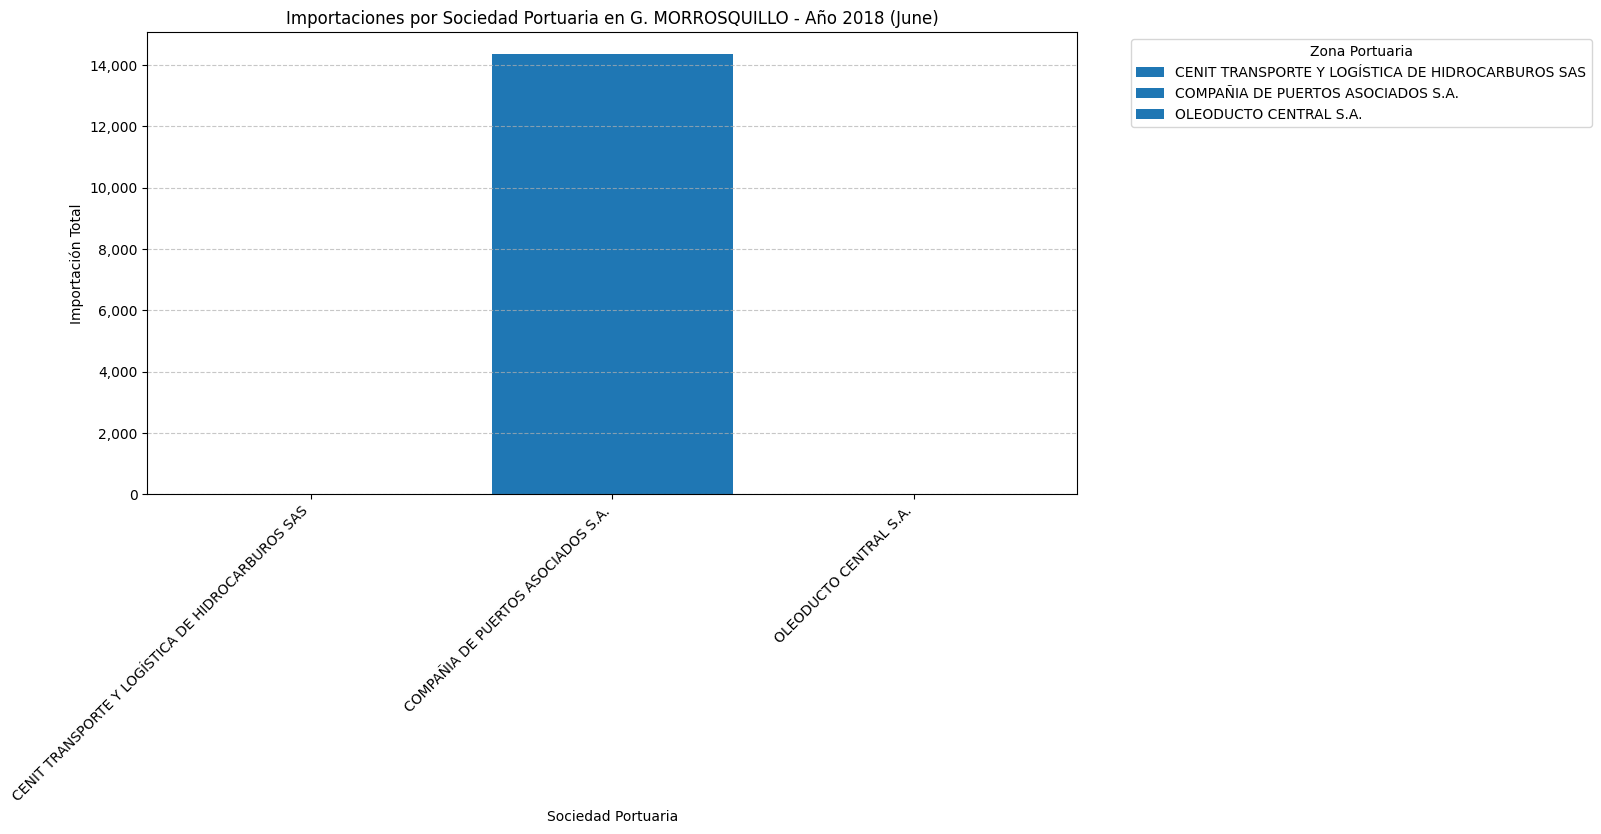

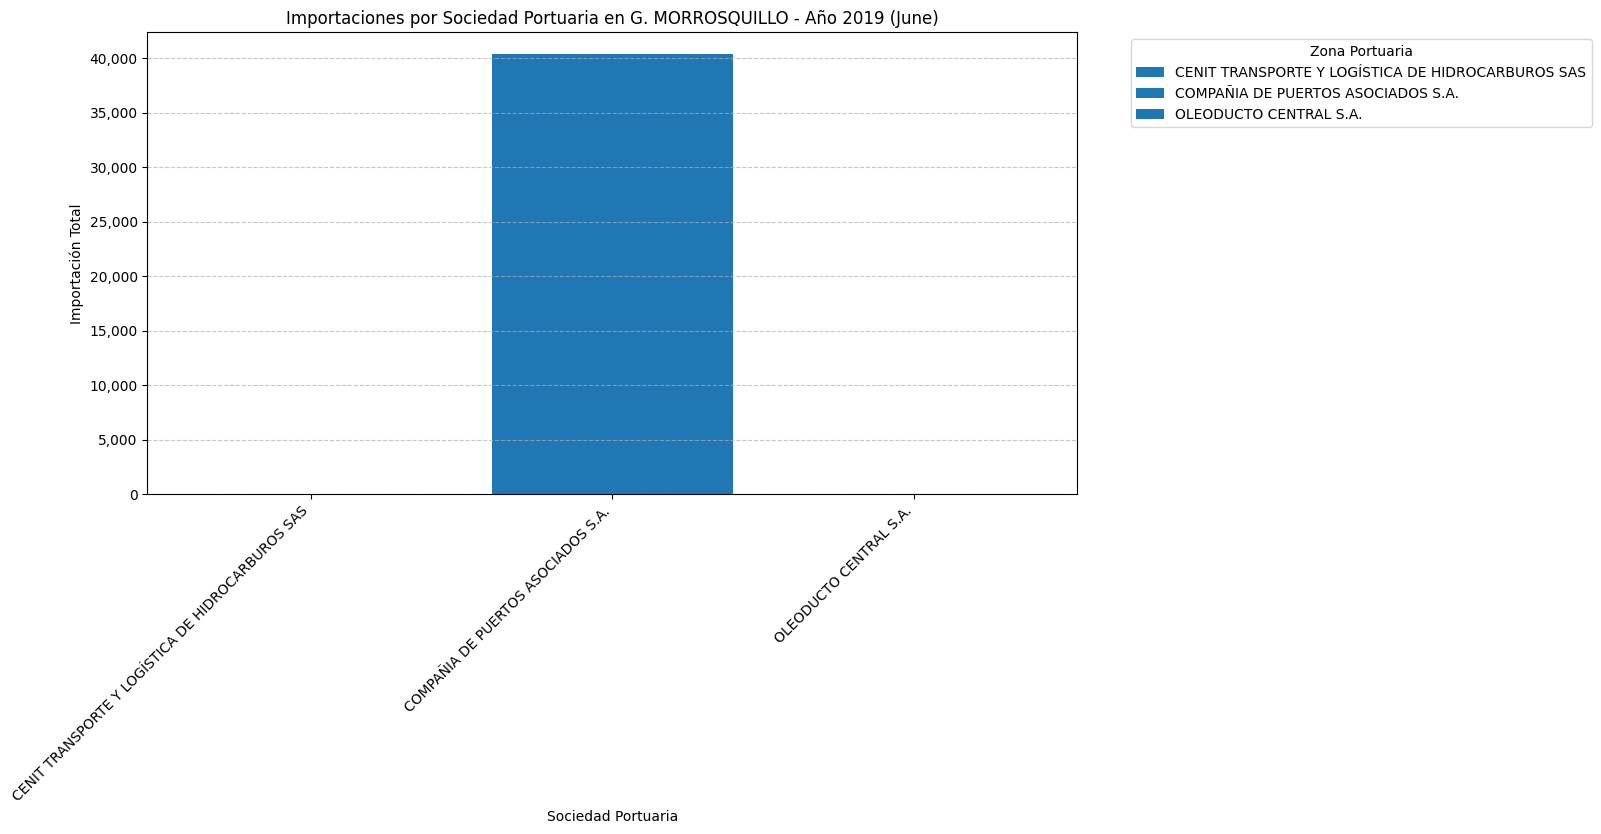

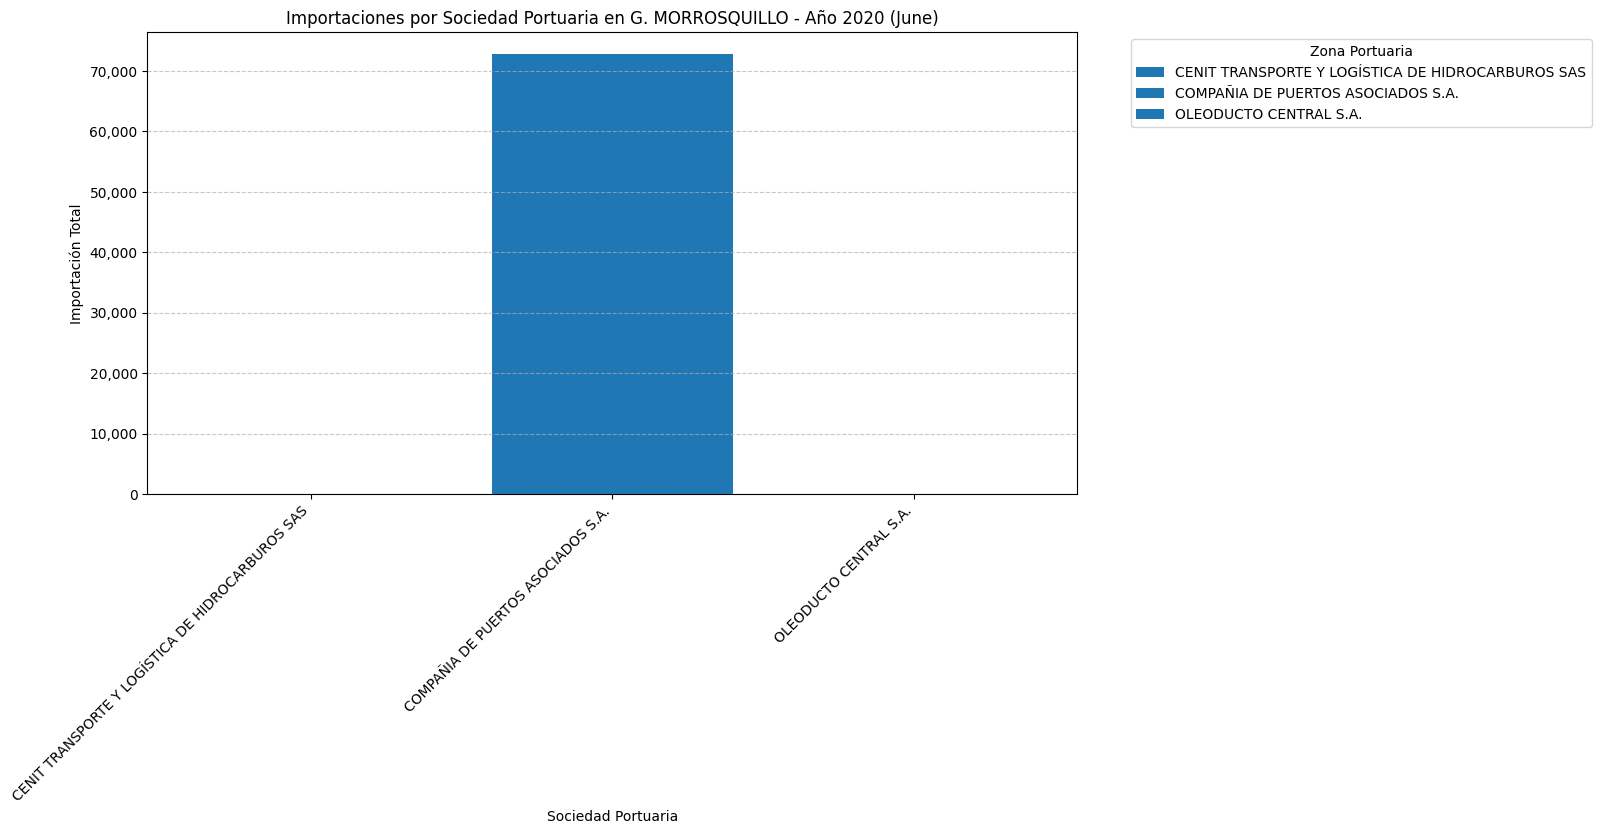

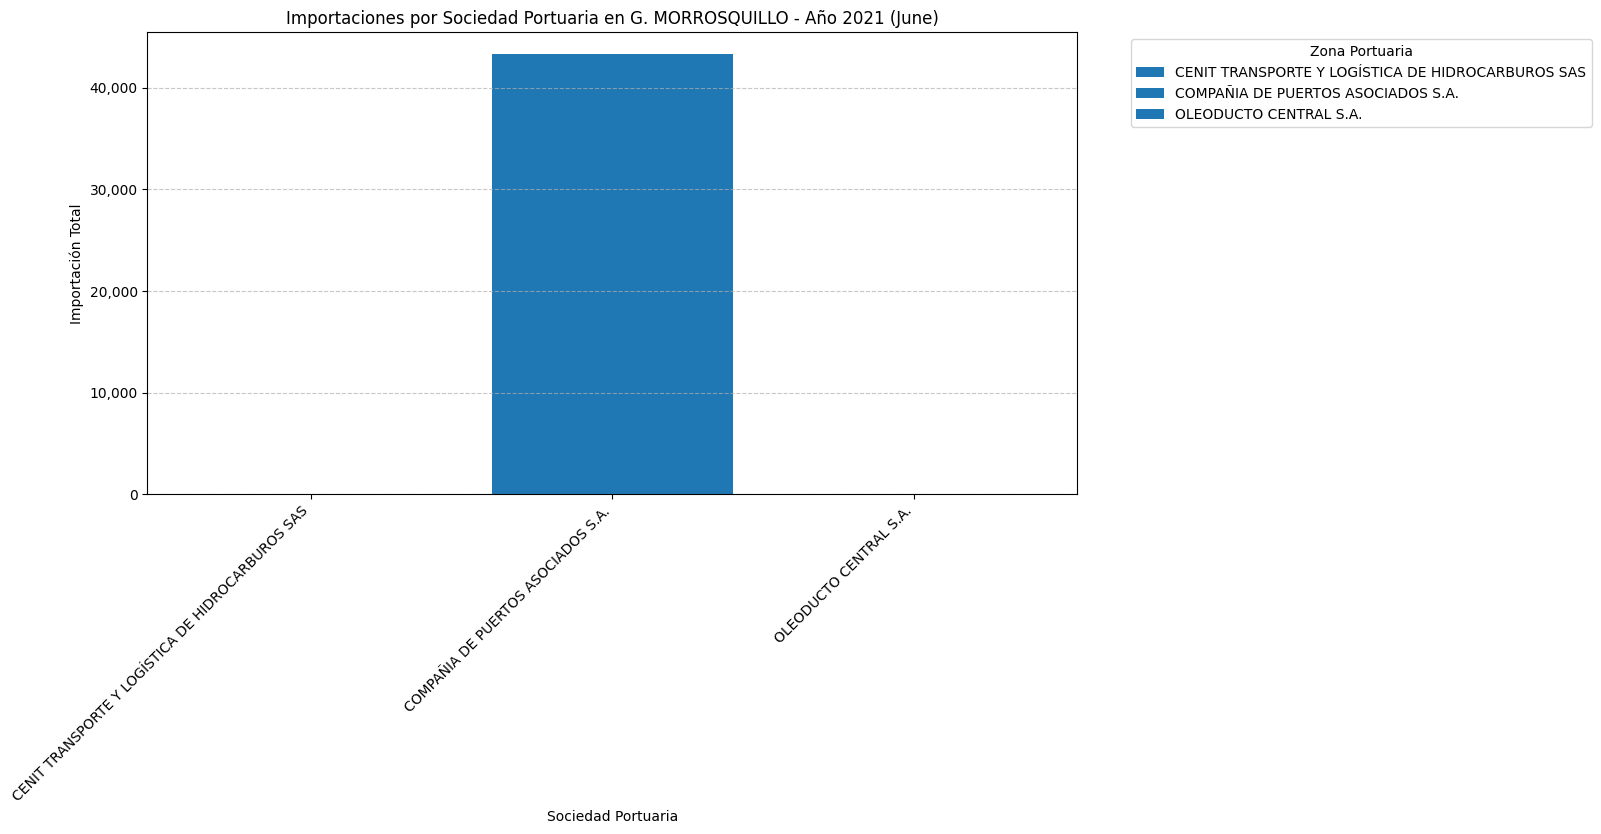

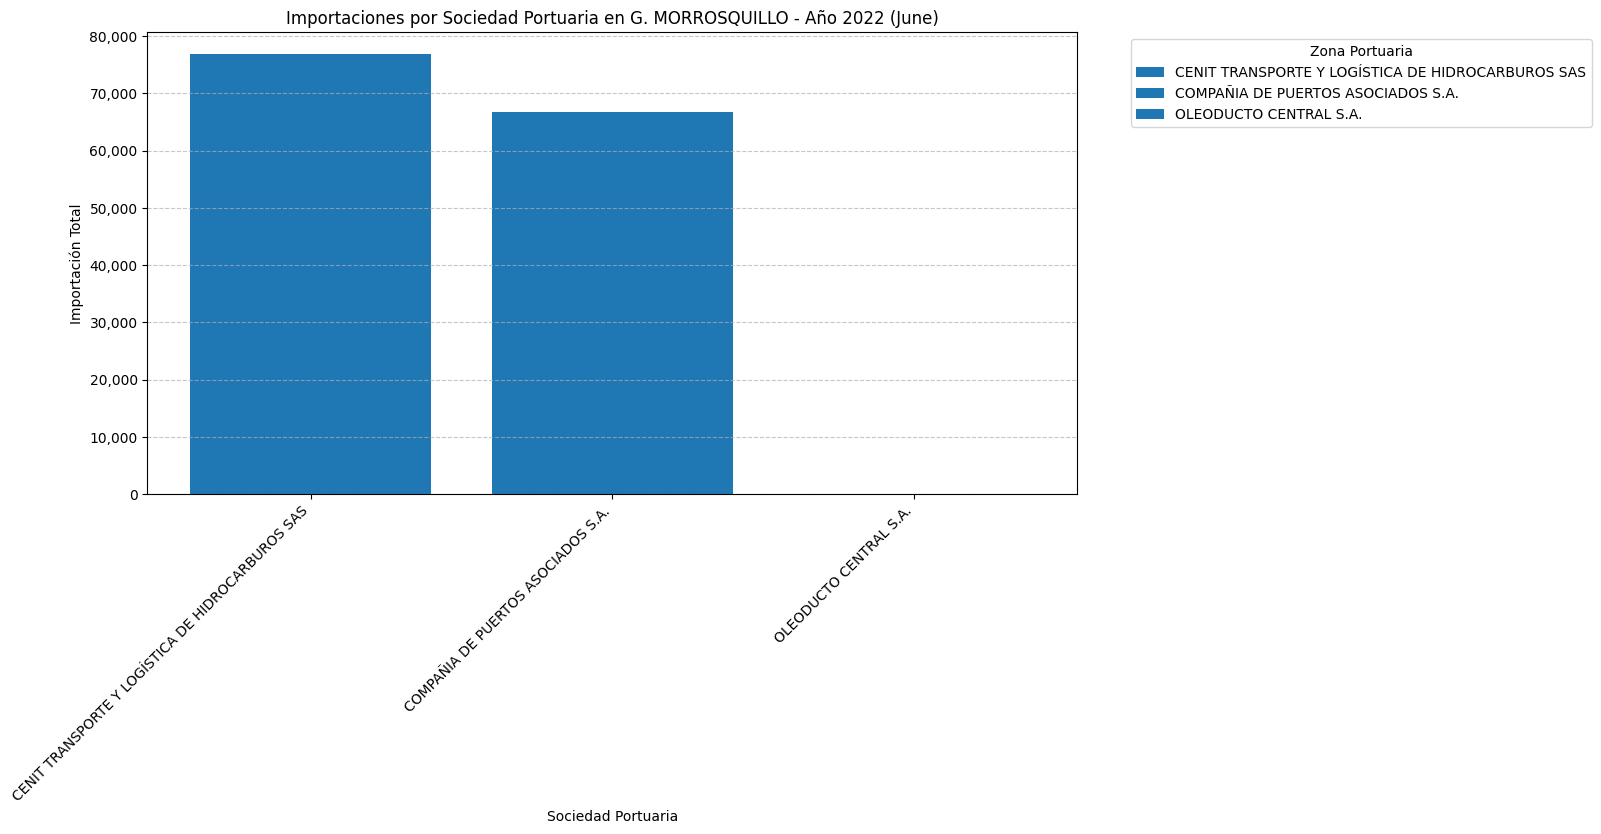

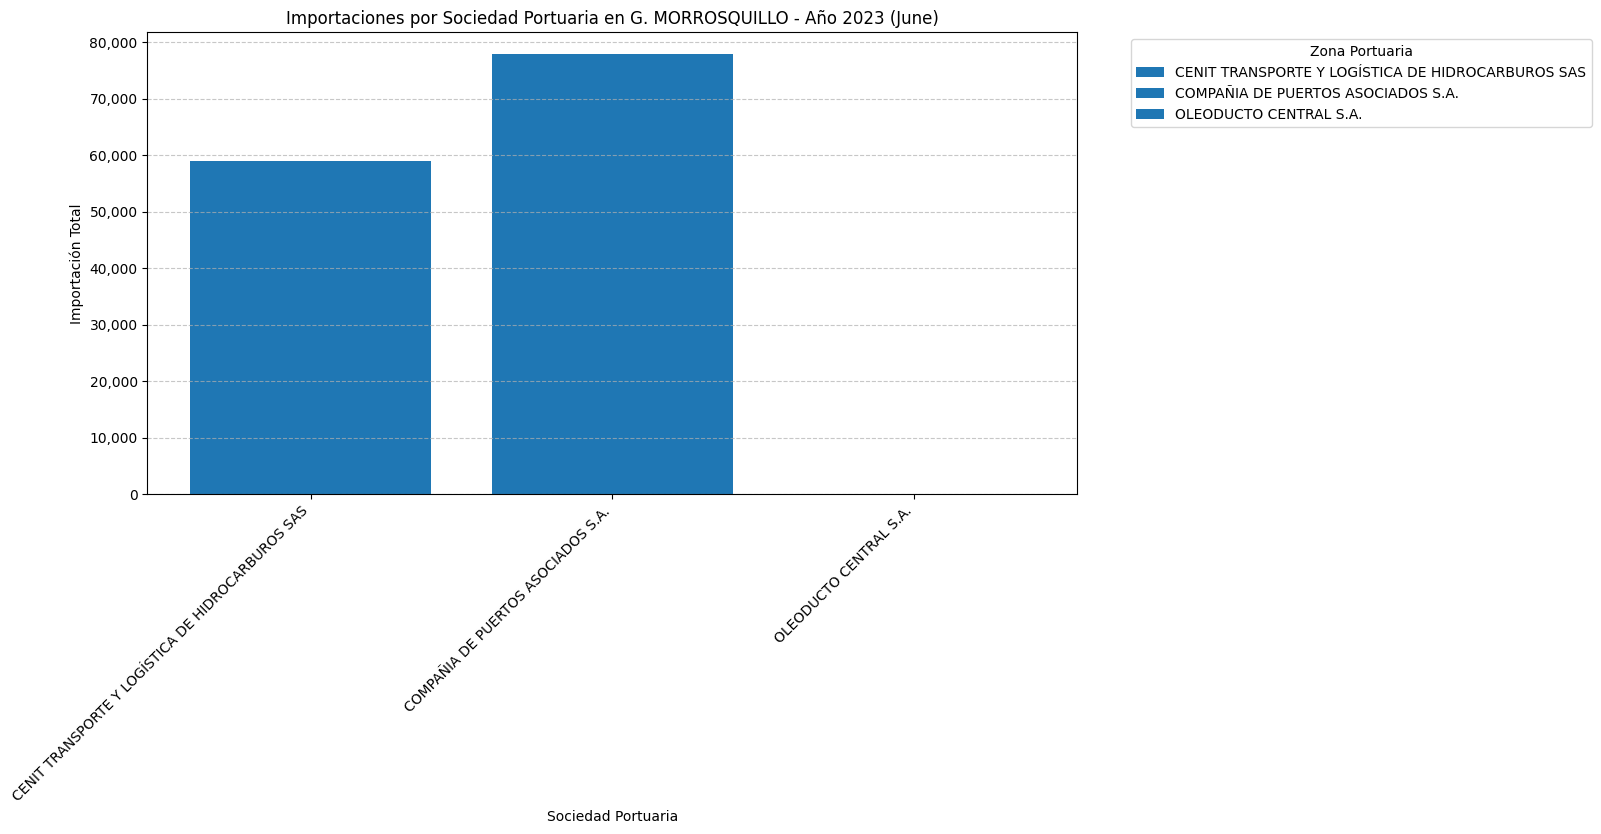

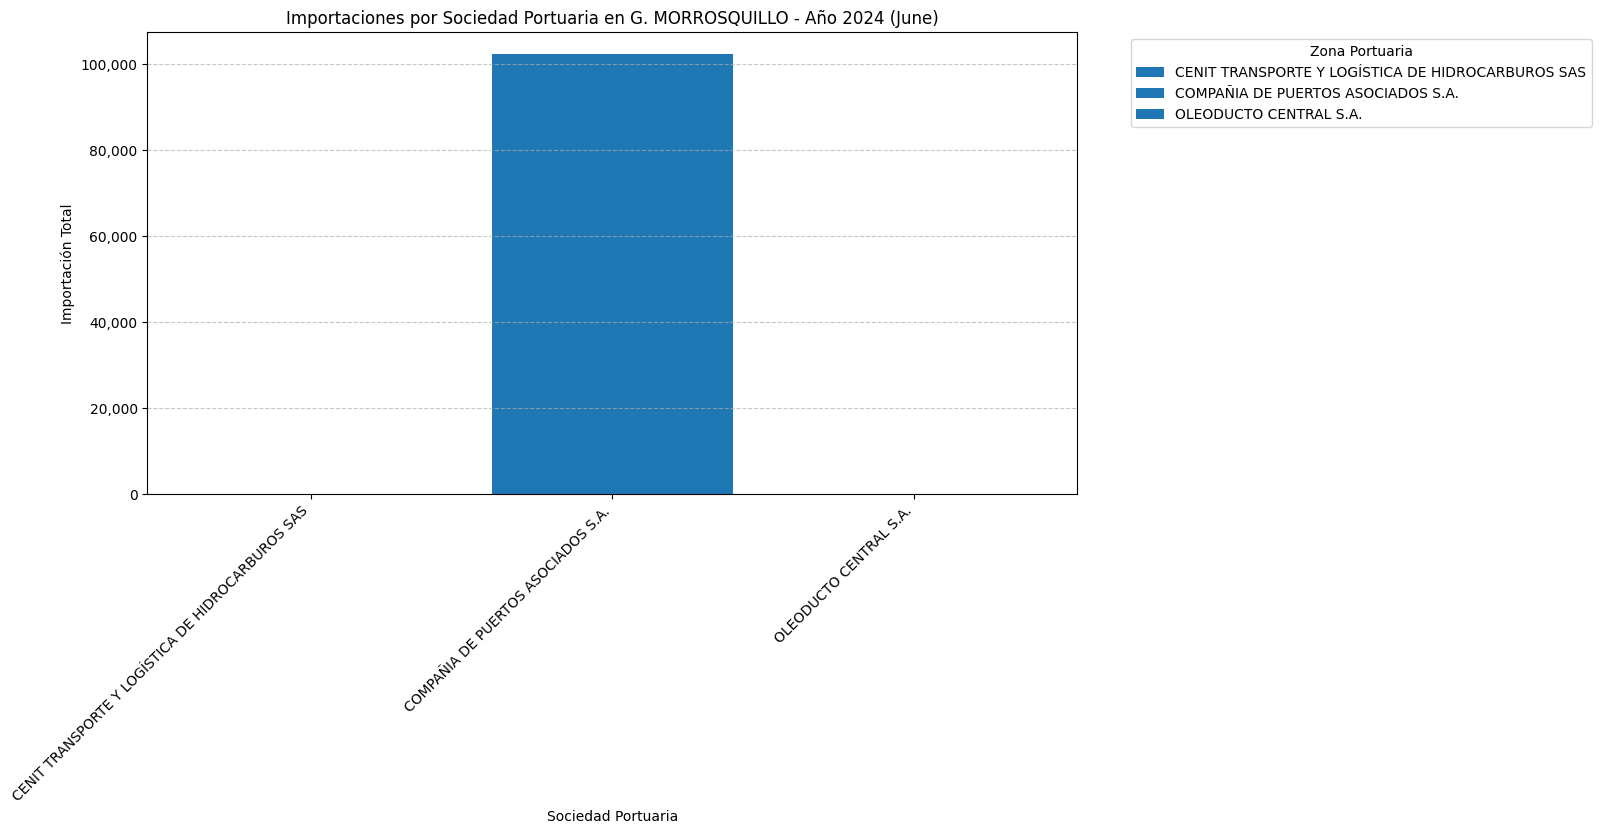

In [89]:
# Obtener el nombre del mes
nombre_mes = pd.to_datetime(str(mes), format='%m').strftime('%B')
años_unicos = sorted(df_mes['AÑO VIGENCIA'].unique())  # Obtener años únicos del mes filtrado

# Iterar sobre cada zona portuaria para generar gráficos separados por año
for zona in zonas_unicas:
    print(f"\nGráficos para {zona} en {nombre_mes}:")

    # Filtrar los datos de la zona actual
    df_zona = df_mes[df_mes["ZONA PORTUARIA"] == zona]

    # Iterar sobre cada año único en los datos filtrados
    for año in años_unicos:
        print("\n")
        df_zona_año = df_zona[df_zona['AÑO VIGENCIA'] == año]  # Filtrar por año

        # Agrupar por sociedad portuaria y calcular el total de importaciones en ese año
        df_sociedad_agg = df_zona_año.groupby("SOCIEDAD PORTUARIA")["IMPORTACIÓN"].sum()

        # Verificar si hay datos para graficar
        if df_sociedad_agg.empty:
            print(f"No hay datos de importación para {zona} en el año {año}.")
            continue

        # Crear la figura
        plt.figure(figsize=(12, 6))

        # Graficar las barras
        plt.bar(df_sociedad_agg.index, df_sociedad_agg.values, label = df_sociedad_agg.index)#color='skyblue', edgecolor='black')

        # Configuración del gráfico
        plt.xticks(rotation=45, ha="right")  # Rotar etiquetas del eje X para mejor visibilidad
        plt.title(f"Importaciones por Sociedad Portuaria en {zona} - Año {año} ({nombre_mes})")
        plt.xlabel("Sociedad Portuaria")
        plt.ylabel("Importación Total")
        plt.legend(title="Zona Portuaria", bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)

        # **Evitar notación científica en el eje Y**
        plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

        plt.grid(axis='y', linestyle='--', alpha=0.7)  # Agregar líneas de guía

        # Mostrar el gráfico
        plt.show()


In [90]:
# Pueba de plotly
import plotly.express as px
import pandas as pd

# Datos de muestra
df = pd.DataFrame(dict(
    grupo = ["A", "B", "C", "D", "E"],
    valor = [14, 12, 8, 10, 16]))

fig = px.bar(df, x = 'grupo', y = 'valor',
             color = 'grupo')

fig.show()


CREACIÓN DE PALETA DE COLORES PARA QUE CADA SOCIEDAD PORTUARIOA TENGA UN ÚNICO COLOR CARACTERÍSTICO

In [91]:
# Obtener el nombre del mes
nombre_mes = pd.to_datetime(str(mes), format='%m').strftime('%B')
años_unicos = sorted(df_mes['AÑO VIGENCIA'].unique())  # Obtener años únicos del mes filtrado

# Obtener todas las sociedades portuarias únicas
sociedades_unicas = df_region5["SOCIEDAD PORTUARIA"].unique()

# Generar una paleta de colores fija (usa el mismo color para cada sociedad en todos los años)
colores = pc.qualitative.Pastel  # Puedes cambiar Set1 por otras paletas como Pastel, Dark, etc.
color_map = {sociedad: colores[i % len(colores)] for i, sociedad in enumerate(sociedades_unicas)}

GRÁFICAS DE UN MES ESPECÍFICO (JUNE EN ESTE CASO) DE CADA AÑO

In [92]:
# Iterar sobre cada zona portuaria para generar gráficos separados por año
for zona in zonas_unicas:
    print(f"\nGráficos para {zona} en {nombre_mes}:")

    # Filtrar los datos de la zona actual
    df_zona = df_mes[df_mes["ZONA PORTUARIA"] == zona]

    # Iterar sobre cada año único en los datos filtrados
    for año in años_unicos:
        print('\n')
        df_zona_año = df_zona[df_zona['AÑO VIGENCIA'] == año]  # Filtrar por año

        # Agrupar por sociedad portuaria y calcular el total de importaciones en ese año
        df_sociedad_agg = df_zona_año.groupby("SOCIEDAD PORTUARIA", as_index=False)["IMPORTACIÓN"].sum()

        df_sociedad_agg["SOCIEDAD PORTUARIA"] = df_sociedad_agg["SOCIEDAD PORTUARIA"].astype(str).str.encode('utf-8').str.decode('utf-8')

        # Verificar si hay datos para graficar
        if df_sociedad_agg.empty:
            print(f"No hay datos de importación para {zona} en el año {año}.")
            continue

        # Crear gráfico de barras con Plotly Express
        fig = px.bar(
            df_sociedad_agg,
            x="SOCIEDAD PORTUARIA",
            y="IMPORTACIÓN",
            color="SOCIEDAD PORTUARIA",  # Asigna un color distinto a cada sociedad
            title=f"Importaciones por Sociedad Portuaria en {zona} - Año {año} ({nombre_mes})",
            labels={"IMPORTACIÓN": "Importación Total", "SOCIEDAD PORTUARIA": "Sociedad Portuaria"},
            hover_data={"IMPORTACIÓN": ":,.0f"},  # Mostrar valores sin notación científica
            color_discrete_map=color_map  # Mantiene colores fijos entre los años
        )

        # Personalizar el gráfico
        fig.update_layout(
            xaxis=dict(tickangle=-45),  # Rotar etiquetas del eje X
            yaxis=dict(tickformat=",d"),  # Evitar notación científica en Y
            legend_title="Sociedad Portuaria",
            bargap=0.2,  # Espaciado entre barras
            #width=max(1400, num_categorias * 60),  # Asegura espacio suficiente
            height=600,  # Ajusta la altura
            margin=dict(l=50, r=50, t=50, b=200),  # Aumenta margen inferior para evitar recortes
            #xaxis_tickangle=-25  # Inclina etiquetas para mejor lectura
        )
        #fig.update_layout(width=200, height=600)
        # Mostrar gráfico
        fig.show()



Gráficos para CARTAGENA en June:





Gráficos para SAN ANDRES en June:





Gráficos para G. MORROSQUILLO en June:




GRÁFICOS DE LINEAS PARA IMPORTACIONES DEL EL MES DE JUNIO PARA CADA UNO DE LOS AÑOS

In [93]:
# Iterar sobre cada zona portuaria para generar gráficos separados por año
for zona in zonas_unicas:
    print(f"\nGráficos para {zona} en {nombre_mes}:")
    # Agrupar por año y sociedad portuaria
    df_zona = df_mes[df_mes["ZONA PORTUARIA"] == zona]
    df_sociedad_agg = df_zona.groupby(["SOCIEDAD PORTUARIA", "AÑO VIGENCIA"], as_index=False)["IMPORTACIÓN"].sum()

    # Crear gráfico de líneas
    fig = px.line(
        df_sociedad_agg,
        x="AÑO VIGENCIA",
        y="IMPORTACIÓN",
        color="SOCIEDAD PORTUARIA",
        title=f"Importaciones por Sociedad Portuaria en {zona} ({nombre_mes})",
        labels={"IMPORTACIÓN": "Importación Total", "SOCIEDAD PORTUARIA": "Sociedad Portuaria"},
        color_discrete_map=color_map # Mantiene colores fijos entre los años
        # hover_data={"IMPORTACIÓN": ":,.0f"}
    )

    # Personalizar el gráfico
    fig.update_layout(
        xaxis=dict(tickangle=-45),  # Rotar etiquetas del eje X
        yaxis=dict(tickformat=",d"),  # Evitar notación científica en Y
        legend_title="Sociedad Portuaria",
        bargap=0.2,  # Espaciado entre barras
        #width=max(1400, num_categorias * 60),  # Asegura espacio suficiente
        height=600,  # Ajusta la altura
        margin=dict(l=50, r=50, t=50, b=200),  # Aumenta margen inferior para evitar recortes
        #xaxis_tickangle=-25  # Inclina etiquetas para mejor lectura
    )
    #fig.update_layout(width=200, height=600)
    # Mostrar gráfico
    fig.show()


Gráficos para CARTAGENA en June:



Gráficos para SAN ANDRES en June:



Gráficos para G. MORROSQUILLO en June:


GRÁFICO DE EXPORTACIONES

In [94]:
# Iterar sobre cada zona portuaria para generar gráficos separados por año
for zona in zonas_unicas:
    print(f"\nGráficos para {zona} en {nombre_mes}:")
    # Agrupar por año y sociedad portuaria
    df_zona = df_mes[df_mes["ZONA PORTUARIA"] == zona]
    df_sociedad_agg = df_zona.groupby(["SOCIEDAD PORTUARIA", "AÑO VIGENCIA"], as_index=False)["EXPORTACION"].sum()

    # Crear gráfico de líneas
    fig = px.line(
        df_sociedad_agg,
        x="AÑO VIGENCIA",
        y="EXPORTACION",
        color="SOCIEDAD PORTUARIA",
        title=f"Exportaciones por Sociedad Portuaria en {zona} ({nombre_mes})",
        labels={"EXPORTACION": "Exportación Total", "SOCIEDAD PORTUARIA": "Sociedad Portuaria"},
        color_discrete_map=color_map # Mantiene colores fijos entre los años
        # hover_data={"IMPORTACIÓN": ":,.0f"}
    )

    # Personalizar el gráfico
    fig.update_layout(
        xaxis=dict(tickangle=-45),  # Rotar etiquetas del eje X
        yaxis=dict(tickformat=",d"),  # Evitar notación científica en Y
        legend_title="Sociedad Portuaria",
        bargap=0.2,  # Espaciado entre barras
        #width=max(1400, num_categorias * 60),  # Asegura espacio suficiente
        height=600,  # Ajusta la altura
        margin=dict(l=50, r=50, t=50, b=200),  # Aumenta margen inferior para evitar recortes
        #xaxis_tickangle=-25  # Inclina etiquetas para mejor lectura
    )
    #fig.update_layout(width=200, height=600)
    # Mostrar gráfico
    fig.show()


Gráficos para CARTAGENA en June:



Gráficos para SAN ANDRES en June:



Gráficos para G. MORROSQUILLO en June:


GRÁFICO DE COMPARACION ENTRE IMPORTACIONES Y EXPORTACIONES

In [95]:
import plotly.graph_objects as go

# Iterar sobre cada zona portuaria para generar gráficos separados por año
for zona in zonas_unicas:
    print(f"\nGráficos para {zona} en {nombre_mes}:")

    # Filtrar datos por zona portuaria
    df_zona = df_mes[df_mes["ZONA PORTUARIA"] == zona]

    # Agrupar datos de importación y exportación por sociedad y año
    df_sociedad_IM = df_zona.groupby(["SOCIEDAD PORTUARIA", "AÑO VIGENCIA"], as_index=False)["IMPORTACIÓN"].sum()
    df_sociedad_EX = df_zona.groupby(["SOCIEDAD PORTUARIA", "AÑO VIGENCIA"], as_index=False)["EXPORTACION"].sum()

    # Crear figura
    fig = go.Figure()

    # Agregar líneas de importación y exportación con `legendgroup`
    for sociedad in sorted(set(df_sociedad_IM["SOCIEDAD PORTUARIA"].unique()) | set(df_sociedad_EX["SOCIEDAD PORTUARIA"].unique())):

        # Importación
        df_temp_IM = df_sociedad_IM[df_sociedad_IM["SOCIEDAD PORTUARIA"] == sociedad]
        if not df_temp_IM.empty:
            fig.add_trace(go.Scatter(
                x=df_temp_IM["AÑO VIGENCIA"],
                y=df_temp_IM["IMPORTACIÓN"],
                mode='lines+markers',
                name=sociedad,  # Solo el nombre de la sociedad
                legendgroup=sociedad,  # Agrupar en la leyenda
                line=dict(color=color_map.get(sociedad, 'black')),
                hovertemplate="<b>Sociedad:</b> %{text}<br><b>Año:</b> %{x}<br><b>Exportación:</b> %{y:,.0f}<extra></extra>",
                text=[sociedad] * len(df_temp_EX),# Se usa para mostrar el nombre completo
            ))

        # Exportación (con leyenda oculta pero mismo `legendgroup`)
        df_temp_EX = df_sociedad_EX[df_sociedad_EX["SOCIEDAD PORTUARIA"] == sociedad]
        if not df_temp_EX.empty:
            fig.add_trace(go.Scatter(
                x=df_temp_EX["AÑO VIGENCIA"],
                y=df_temp_EX["EXPORTACION"],
                mode='lines+markers',
                name=sociedad,  # Mismo nombre
                legendgroup=sociedad,  # Mismo grupo de leyenda
                showlegend=False,  # Ocultar en la leyenda
                line=dict(color=color_map.get(sociedad, 'black'), dash='dash'),  # Línea discontinua
                hovertemplate="<b>Sociedad:</b> %{text}<br><b>Año:</b> %{x}<br><b>Exportación:</b> %{y:,.0f}<extra></extra>",
                text=[sociedad] * len(df_temp_EX), # Se usa para mostrar el nombre completo
            ))

    # Personalizar el gráfico
    fig.update_layout(
        title=f"Importaciones (Línea continua) y Exportaciones (Línea Punteada) por Sociedad Portuaria en {zona} ({nombre_mes}). ",
        xaxis=dict(title="Año Vigencia", tickangle=-45),
        yaxis=dict(title="Valor Total", tickformat=",d"),
        legend_title="Sociedad Portuaria",
        height=600,
        margin=dict(l=50, r=50, t=50, b=200),
    )


    # Mostrar gráfico
    fig.show()



Gráficos para CARTAGENA en June:



Gráficos para SAN ANDRES en June:



Gráficos para G. MORROSQUILLO en June:


In [96]:
import plotly.express as px

# Crear gráfico de barras
fig = px.bar(
    df_sociedad_agg,
    x="SOCIEDAD PORTUARIA",
    y="IMPORTACIÓN",
    color="SOCIEDAD PORTUARIA",
    title=f"Importaciones por Sociedad Portuaria en {zona} - Año {año} ({nombre_mes})",
    labels={"IMPORTACIÓN": "Importación Total", "SOCIEDAD PORTUARIA": "Sociedad Portuaria"},
    hover_data={"IMPORTACIÓN": ":,.0f"}
)

# Ajustar dinámicamente el tamaño del gráfico según el número de categorías
num_categorias = len(df_sociedad_agg)
fig.update_layout(
    width=max(1400, num_categorias * 60),  # Asegura espacio suficiente
    height=600,  # Ajusta la altura
    margin=dict(l=50, r=50, t=50, b=200),  # Aumenta margen inferior para evitar recortes
    xaxis_tickangle=-25  # Inclina etiquetas para mejor lectura
)

# Mostrar gráfico
fig.show()


ValueError: Value of 'y' is not the name of a column in 'data_frame'. Expected one of ['SOCIEDAD PORTUARIA', 'AÑO VIGENCIA', 'EXPORTACION'] but received: IMPORTACIÓN

In [97]:
# Gráfico de prueba para cartagena
import plotly.express as px
df_zona = df_mes[df_mes["ZONA PORTUARIA"] == 'CARTAGENA']

# Agrupar por año y sociedad portuaria
df_sociedad_agg = df_zona.groupby(["SOCIEDAD PORTUARIA", "AÑO VIGENCIA"], as_index=False)["IMPORTACIÓN"].sum()

# Crear gráfico de líneas
fig = px.line(
    df_sociedad_agg,
    x="AÑO VIGENCIA",
    y="IMPORTACIÓN",
    color="SOCIEDAD PORTUARIA",
    color_discrete_map=color_map
    # title=f"Importaciones por Sociedad Portuaria en {zona} ({nombre_mes})",
    # labels={"IMPORTACIÓN": "Importación Total", "SOCIEDAD PORTUARIA": "Sociedad Portuaria"},
    # hover_data={"IMPORTACIÓN": ":,.0f"}
)

fig.show()


In [ ]:
#  ---------- Leyendas -----------------------------------------
# Agregar leyenda manual para Importaciones y Exportaciones
#     fig.add_trace(go.Scatter(
#         x=[None], y=[None],  # No se graficará
#         mode='lines', line=dict(color='black', dash='solid'),
#         name="Importaciones (Línea Continua)"
#     ))

#     fig.add_trace(go.Scatter(
#         x=[None], y=[None],  # No se graficará
#         mode='lines', line=dict(color='black', dash='dash'),
#         name="Exportaciones (Línea Punteada)"
#     ))
# ---------------------------------------------------------------

In [110]:
!apt-get install -y wkhtmltopdf
!pip install pdfkit


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
wkhtmltopdf is already the newest version (0.12.6-2).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.


In [120]:
import plotly.express as px
import pdfkit
import os

# Crear una lista para almacenar los archivos HTML generados
html_files = []

#Años a estudiar
años = range(2019, 2025)

# Iterar sobre cada zona portuaria para generar gráficos separados por año
for año in años:
    df_año = df_region5[df_region5['Fecha'].dt.year == año]
    nombre_año = str(año)

    for zona in zonas_unicas:
        df_zona = df_año[df_año["ZONA PORTUARIA"] == zona]
        df_sociedad_agg = df_zona.groupby(["SOCIEDAD PORTUARIA", "MES VIGENCIA"], as_index=False)["EXPORTACION"].sum()

        fig = px.line(
            df_sociedad_agg,
            x="MES VIGENCIA",
            y="EXPORTACION",
            color="SOCIEDAD PORTUARIA",
            title=f"Exportaciones por Sociedad Portuaria en {zona} ({nombre_año})",
            labels={"EXPORTACION": "Exportación Total", "SOCIEDAD PORTUARIA": "Sociedad Portuaria"},
            color_discrete_map=color_map
        )

        fig.update_layout(
            xaxis=dict(tickangle=-45),
            yaxis=dict(tickformat=",d"),
            legend_title="Sociedad Portuaria",
            bargap=0.2,
            height=600,
            margin=dict(l=50, r=50, t=50, b=200),
        )

        # Guardar el gráfico como HTML
        html_file = f"grafico_{zona}_{nombre_año}.html"
        fig.write_html(html_file)
        html_files.append(html_file)

# Crear un archivo HTML combinando todos los gráficos
html_combined = "todos_los_graficos.html"
with open(html_combined, "w") as f:
    for file in html_files:
        with open(file, "r") as html:
            f.write(html.read())
            f.write("<hr>")  # Separador entre gráficos

# Convertir el HTML combinado a PDF
# pdf_file = "graficos_exportaciones.pdf"
# pdfkit.from_file(html_combined, pdf_file)

pdfkit.from_file('todos_los_graficos.html', 'out.pdf')

# Descargar el PDF generado
from google.colab import files
# files.download(pdf_file)
files.download('out.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [123]:
!pip install PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 3.9 MB/s eta 0:00:00


In [127]:
from PyPDF2 import PdfReader

# Leer contenido del PDF
pdf_reader = PdfReader("/content/drive/MyDrive/BOOTCAMP UTB/Lorem.pdf")
texto_pdf = "".join([page.extract_text() for page in pdf_reader.pages])

# Reemplazar saltos de línea de manera segura
texto_pdf_html = texto_pdf.replace("\n", "<br>")

# Crear HTML con el texto del PDF
html_pdf = f"<h1>Reporte PDF</h1><p>{texto_pdf_html}</p>"

# Fusionar con los gráficos
with open("todos_los_graficos.html", "r") as f:
    contenido_html = html_pdf + "<hr>" + f.read()

# Guardar HTML combinado
with open("graficos_y_pdf.html", "w") as f:
    f.write(contenido_html)


In [128]:
from google.colab import files
files.download("graficos_y_pdf.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [150]:
!pip install -U kaleido
#!pip install --upgrade "kaleido==0.1.*"

In [149]:
import plotly.express as px
import os

imagenes = []
años = range(2019, 2025)

for año in años:
    df_año = df_region5[df_region5['Fecha'].dt.year == año]
    nombre_año = str(año)

    for zona in zonas_unicas:
        df_zona = df_año[df_año["ZONA PORTUARIA"] == zona]
        df_sociedad_agg = df_zona.groupby(["SOCIEDAD PORTUARIA", "MES VIGENCIA"], as_index=False)["EXPORTACION"].sum()

        fig = px.line(
            df_sociedad_agg,
            x="MES VIGENCIA",
            y="EXPORTACION",
            color="SOCIEDAD PORTUARIA",
            title=f"Exportaciones en {zona} ({nombre_año})",
            labels={"EXPORTACION": "Exportación Total", "SOCIEDAD PORTUARIA": "Sociedad Portuaria"},
            color_discrete_map=color_map
        )

        fig.update_layout(xaxis=dict(tickangle=-45), yaxis=dict(tickformat=",d"), height=600)

        # Guardar la imagen
        imagen_file = f"grafico_{zona}_{nombre_año}.png"
        fig.write_image(imagen_file, format="png")
        imagenes.append(imagen_file)


ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
